This notebook is used to create gender-specific epidemiological networks from the disease trajectories

In [46]:
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import pandas as pd
from collections import (defaultdict,Counter)
import matplotlib.pyplot as plt
import scipy  
from scipy import stats
import seaborn as sns


In [2]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

def overlap_genelists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))



#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [3]:
#Here, we define the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

In [4]:
#Let's import the ICD-gene associations
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [5]:
#Let's import the unified gene annotations lcc z-score
with open('output/allsources_icd_gene_dict_unified_lcczscore_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)


In [6]:
#Let's create a phenotypic epidemiological network from Elma trajectories 

In [6]:
#Let's import the trajectories

male_trajectories_df=pd.read_excel('input/All identified trajectories in males. trajectories smaller than 100 members.xlsx')
female_trajectories_df=pd.read_excel('input/All identified trajectories in females. trajectories smaller than 100 members.xlsx')

# Males

In [7]:
male_trajectories_df_copy=pd.DataFrame()
male_trajectories_df_copy['Community_ID']=male_trajectories_df['Community_ID']

new_members_of_com_list=[]
for i in male_trajectories_df['Members of community'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
male_trajectories_df_copy['Members of community']=new_members_of_com_list

male_trajectories_df_copy.head()

,Community_ID,Members of community
0,1,"K35-10-19,K37-10-19,K56-10-19,K65-10-19"
1,2,"A04-0-9,A08-0-9,B09-0-9,F50-0-9,J10-0-9"
2,3,"A09-0-9,H73-0-9,K92-0-9"
3,4,"A41-0-9,C91-0-9,N10-0-9,A41-10-19,C91-10-19"
4,5,"A49-0-9,B27-0-9,J03-0-9,J06-0-9,J11-0-9,J38-0-..."


In [8]:

male_trajectories_dict={}
for i,v in male_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members of community'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in allsources_icd_gene_dict_unified.keys():
            dis_list.append(dis)
    male_trajectories_dict[v['Community_ID']]=dis_list

#Now, let's remove all the trajectories that are obvious (same disease)
male_trajectories_dict_filtered={}
for trj,dislist in male_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in allsources_icd_gene_dict_unified.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        male_trajectories_dict_filtered[trj]=new_dislist

print(len(male_trajectories_dict_filtered))


362


In [10]:
#Some of these disease-trajectories contain the same diseases, for this reason, now we will focus only on the
#unique disease-trajectories

In [9]:
#Let's select only those communities that are unique (avoiding repetitions)

def agglomerate_dict(dict_list):
    # Reverse the dictionary: lists are keys, strings are values
    temp_dict = {}
    for k, v in dict_list.items():
        v = tuple(v)  # lists can't be hashable (used as keys), so convert it to tuple
        if v not in temp_dict:
            temp_dict[v] = [str(k)]
        else:
            temp_dict[v].append(str(k))
    
    # Agglomerate the keys that have the same list and return
    result_dict = {'_'.join(v): list(k) for k, v in temp_dict.items()}
    
    return result_dict

In [10]:
male_trajectories_dict_filtered_unique=agglomerate_dict(male_trajectories_dict_filtered)
print(len(male_trajectories_dict_filtered_unique))

329


In [11]:
len(set([x for xs in list(male_trajectories_dict_filtered_unique.values()) for x in xs]))

504

In [12]:
with open('output/male_trajectories_dict_filtered_v2026_official.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/male_trajectories_dict_filtered_unique_v2026_official.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered_unique, handle, protocol=pk.HIGHEST_PROTOCOL)

In [12]:
male_trajectories_dict_filtered_unique_agglomerated_genes={}

for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    male_trajectories_dict_filtered_unique_agglomerated_genes[agg_trj]=tot_genelsit

In [14]:
with open('output/male_trajectories_dict_filtered_unique_agglomerated_genes_v2026_official.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered_unique_agglomerated_genes, handle, protocol=pk.HIGHEST_PROTOCOL)

In [13]:
male_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in male_trajectories_dict_filtered_unique.items():
    overlap_list=[]
    pair_diseases_list=list(it.combinations(dislist,2))
    for p_dis in pair_diseases_list:
        try:
            overlap_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[0]],allsources_icd_gene_dict_unified[p_dis[1]]))
        except:
            overlap_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[1]],allsources_icd_gene_dict_unified[p_dis[0]]))
    if len(overlap_list)>0:
        male_trajectories_dict_filtered_unique_avg_overlap[com]=np.mean(overlap_list) 
  

In [14]:
for trj,avg_overlap in male_trajectories_dict_filtered_unique_avg_overlap.items():
    if avg_overlap>0.8 and len(male_trajectories_dict_filtered_unique[trj])<8:
        print(trj,male_trajectories_dict_filtered_unique[trj])

67 ['B20', 'B24']


In [15]:
#Let's compare against a null distribution

rd_male_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in male_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(list(allsources_icd_gene_dict_unified.keys()),len(dislist))
    for i in range(1000):
        pair_diseases_list=list(it.combinations(random_dislist,2))
        for p_dis in pair_diseases_list:
            try:
                rd_overlap_distribution.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[0]],allsources_icd_gene_dict_unified[p_dis[1]]))
            except:
                rd_overlap_distribution.append(overlap_jaccard(allsources_icd_gene_dict_unified[p_dis[1]],allsources_icd_gene_dict_unified[p_dis[0]]))

    rd_male_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_56358/2439839315.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


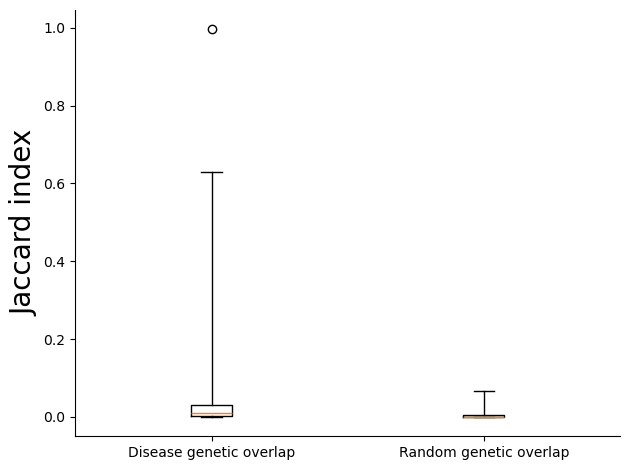

In [16]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_male_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.mean(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()
#plt.savefig('Figures/MaleTrajectories_JI_Random.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [17]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

8.254364521563909e-10

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_56358/1007135948.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


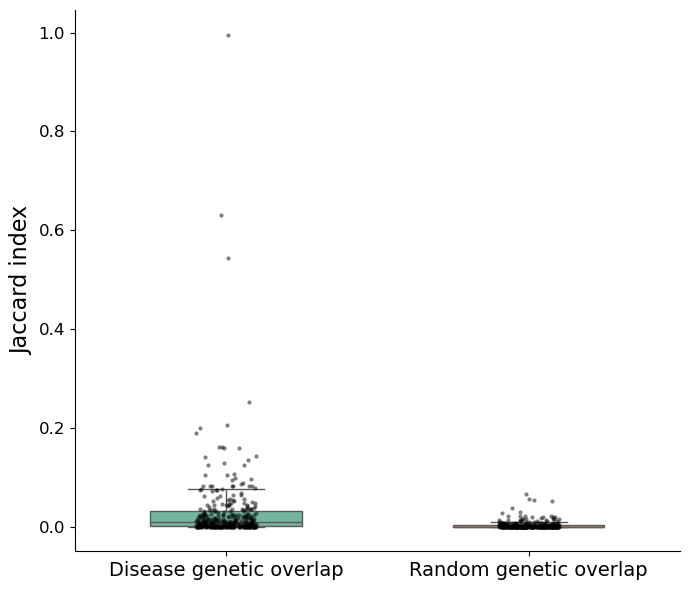

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure fonts remain editable in Illustrator/Inkscape
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# Prepare data
rd_ov_list = [np.mean(ov_distribution) for ov_distribution in rd_male_trajectories_dict_filtered_unique_avg_overlap.values()]

df_plot = pd.DataFrame({
    "value": list(male_trajectories_dict_filtered_unique_avg_overlap.values()) + rd_ov_list,
    "group": (["Disease genetic overlap"] * len(male_trajectories_dict_filtered_unique_avg_overlap)) +
             (["Random genetic overlap"] * len(rd_ov_list))
})

# Create figure
plt.figure(figsize=(7,6))
sns.boxplot(
    data=df_plot,
    x="group",
    y="value",
    showfliers=False,   # hide extreme outliers
    width=0.5,
    palette="Set2"
)
sns.stripplot(
    data=df_plot,
    x="group",
    y="value",
    color="black",
    alpha=0.5,
    jitter=True,
    size=3
)

# Labels
plt.ylabel("Jaccard index", fontsize=16)
plt.xlabel("", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)

sns.despine()
plt.tight_layout()

# Save in vector formats (text editable)
plt.savefig("Figures/MaleTrajectories_JI_Random_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/MaleTrajectories_JI_Random_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

In [19]:


# Disease overlap values
disease_values = [
    v for v in male_trajectories_dict_filtered_unique_avg_overlap.values()
    if pd.notna(v)
]

# Random overlap (median per distribution)
rd_ov_list = [
    np.median(ov_distribution)
    for ov_distribution in rd_male_trajectories_dict_filtered_unique_avg_overlap.values()
]

rd_ov_list = [v for v in rd_ov_list if pd.notna(v)]

# -----------------------------
# 2. Build long-format dataframe
# -----------------------------
df_plot = pd.DataFrame({
    "value": disease_values + rd_ov_list,
    "group": (["Disease genetic overlap"] * len(disease_values)) +
             (["Random genetic overlap"] * len(rd_ov_list))
})

# Deterministic ordering
df_plot = df_plot.sort_values(["group", "value"]).reset_index(drop=True)

# -----------------------------
# 3. Add metadata rows
# -----------------------------
df_plot["metadata"] = None

metadata_entries = [
    f"N_Disease_genetic_overlap: {len(disease_values)}",
    f"N_Random_genetic_overlap: {len(rd_ov_list)}",
    "Random values = median of each random overlap distribution",
    "Boxplot: showfliers=False",
    "Stripplot: alpha=0.5, jitter=True"
]

metadata_df = pd.DataFrame({
    "value": [None]*len(metadata_entries),
    "group": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([df_plot, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a",if_sheet_exists="replace") as writer:
    source_df.to_excel(writer, sheet_name="Fig3C", index=False)

print(f"Source data saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_56358/1298433550.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([df_plot, metadata_df], ignore_index=True)


Source data saved to output/SourceData.xlsx


In [21]:
tot_filtered_dis_list=[]
for dislist in male_trajectories_dict_filtered_unique.values():
    for dis in dislist:
        if dis not in tot_filtered_dis_list:
            tot_filtered_dis_list.append(dis)
            
print(len(tot_filtered_dis_list))

504


In [22]:
#Let's compare against a null distribution, where we sample only among the 504 diseases present in the disease trajectories

rd_male_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in male_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(tot_filtered_dis_list,len(dislist))
    for i in range(1000):
        for rd_dis1 in random_dislist:
            for rd_dis2 in random_dislist:
                if rd_dis1!=rd_dis2:
                    rd_overlap_distribution.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[rd_dis1],allsources_icd_gene_dict_unified[rd_dis2])))
                
    rd_male_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution
    
    

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_56358/671204940.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


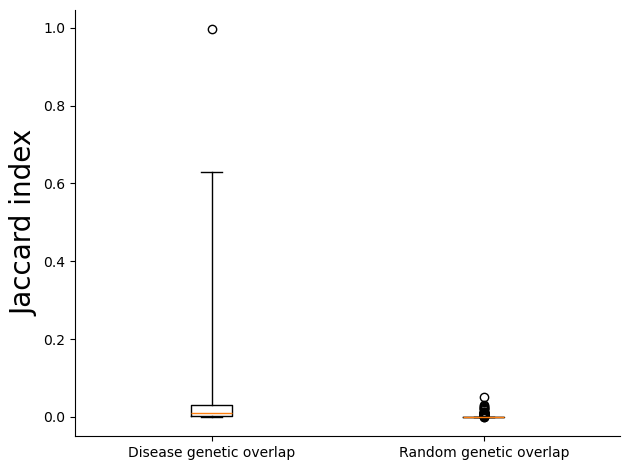

In [23]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_male_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.median(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

In [24]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(male_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

2.572539161346658e-11

In [25]:
#Now, we will look more in the details of this shared relationships, computing the pairs/triplets and so on
#and comparing accordingly each community against its corresponding random distribution
dis_list=list(allsources_icd_gene_dict_unified.keys())
pair_diseases_list=list(it.combinations(dis_list,2))

In [26]:
jaccard_pairs_reference_list=[]

for dispair in pair_diseases_list:
    jaccard_pairs_reference_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
    
print(len(jaccard_pairs_reference_list))

292995


In [27]:
jaccard_pairs_from_n_plets_elma_list_dict={}
jaccard_pairs_from_n_plets_elma_list_pval_dict={}
jaccard_pairs_from_n_plets_elma_list_fdr_dict={}

for s in set([len(v) for v in male_trajectories_dict_filtered_unique.values()]):

    jaccard_pairs_from_n_plets_elma_list=[]
    selected_disnlets=[]
    for trj,dislist in male_trajectories_dict_filtered_unique.items():
        if len(dislist)==s:
            if dislist not in selected_disnlets:
                selected_disnlets.append(dislist)

    selected_dispair_fromnplets=[]
    for disqua in selected_disnlets:
        jo_list=[]
        dispairdisn=list(it.combinations(disqua,2))          
        for dispair in dispairdisn:
            if dispair not in selected_dispair_fromnplets:
                selected_dispair_fromnplets.append(dispair)

    for dispair in selected_dispair_fromnplets:
        try:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
        except:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
            
    jaccard_pairs_from_n_plets_elma_list_dict[s]=jaccard_pairs_from_n_plets_elma_list

    t_value,p_value=stats.ttest_ind(jaccard_pairs_reference_list,jaccard_pairs_from_n_plets_elma_list)
    jaccard_pairs_from_n_plets_elma_list_pval_dict[s] = p_value

adj_pval=fdr_adjustment(list(jaccard_pairs_from_n_plets_elma_list_pval_dict.values()),0.05)
pair_list=list(jaccard_pairs_from_n_plets_elma_list_pval_dict.keys())
for i in range(len(adj_pval)):
    jaccard_pairs_from_n_plets_elma_list_fdr_dict[pair_list[i]]=adj_pval[i]


In [28]:
jaccard_pairs_from_n_plets_elma_list_fdr_dict

{2: 1.6732952503576953e-89,
 3: 6.842363178138207e-143,
 4: 6.801676712939874e-58,
 5: 6.477429340790237e-22,
 6: 7.705845790329136e-32,
 7: 2.8697771177349718e-95,
 8: 1.735622660348233e-31,
 9: 2.8481660566265464e-12,
 10: 3.451907545073175e-08,
 11: 3.620260147275809e-06,
 12: 0.0016452725710016567,
 13: 0.9005243367186386,
 14: 0.9005243367186386,
 34: 0.9240334889892257,
 16: 0.003361191898965565,
 18: 5.8879560031181e-08,
 57: 0.9005243367186386,
 28: 0.09016269627119813}

In [29]:
with open('output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_male_v2026_official.pickle', 'wb') as handle:
    pk.dump(jaccard_pairs_from_n_plets_elma_list_fdr_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [20]:

with open('output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_male_v2026_official.pickle', 'rb') as handle:
    jaccard_pairs_from_n_plets_elma_list_fdr_dict = pk.load(handle)

jaccard_pairs_from_n_plets_elma_list_fdr_dict

{2: 1.6732952503576953e-89,
 3: 6.842363178138207e-143,
 4: 6.801676712939874e-58,
 5: 6.477429340790237e-22,
 6: 7.705845790329136e-32,
 7: 2.8697771177349718e-95,
 8: 1.735622660348233e-31,
 9: 2.8481660566265464e-12,
 10: 3.451907545073175e-08,
 11: 3.620260147275809e-06,
 12: 0.0016452725710016567,
 13: 0.9005243367186386,
 14: 0.9005243367186386,
 34: 0.9240334889892257,
 16: 0.003361191898965565,
 18: 5.8879560031181e-08,
 57: 0.9005243367186386,
 28: 0.09016269627119813}

In [30]:
import csv
import os

data = {2: 1.6732952503576953e-89,
 3: 6.842363178138207e-143,
 4: 6.801676712939874e-58,
 5: 6.477429340790237e-22,
 6: 7.705845790329136e-32,
 7: 2.8697771177349718e-95,
 8: 1.735622660348233e-31,
 9: 2.8481660566265464e-12,
 10: 3.451907545073175e-08,
 11: 3.620260147275809e-06,
 12: 0.0016452725710016567,
 13: 0.9005243367186386,
 14: 0.9005243367186386,
 34: 0.9240334889892257,
 16: 0.003361191898965565,
 18: 5.8879560031181e-08,
 57: 0.9005243367186386,
 28: 0.09016269627119813}

# Ensure output directory exists (optional, matches your R script path)
os.makedirs('output', exist_ok=True)
filename = 'output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_male_v2026_official.csv'

with open(filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['key', 'value'])  # Header required by your R script
    for key, value in data.items():
        writer.writerow([key, value])

print(f"File saved to {filename}")

File saved to output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_male_v2026_official.csv


In [42]:
#Here, we calculate the average shortest path of the DDN, and we compare the distribution of average shortest path
#between disease pairs within the same trajectory versus the average shortest path of the DDN

#Let's import the ICD Genetic network
G_gene_icd_disp_significant_post_df = pd.read_csv("output/G_gene_icd_disp_significant_post_df_v2026_official.tsv", sep="\t",index_col=0)
G_gene_icd_disp_significant_post = nx.from_pandas_edgelist(G_gene_icd_disp_significant_post_df, 'Dis A', 'Dis B')

#Let's extract the lcc
G_gene_icd_disp_significant_post_lcc = G_gene_icd_disp_significant_post.subgraph(max(nx.connected_components(G_gene_icd_disp_significant_post), key=len))

#Avg shortest path
G_gene_icd_disp_significant_post_avg_sp = nx.average_shortest_path_length(G_gene_icd_disp_significant_post_lcc)

In [22]:
male_trajectories_dict_filtered_unique_DDN_avgsp = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    sp_list = []
    n_dislist = set(dislist) & G_gene_icd_disp_significant_post_lcc.nodes()
    pair_diseases_list=list(it.combinations(n_dislist,2))
    for dispair in pair_diseases_list:
        sp_list.append(nx.shortest_path_length(G_gene_icd_disp_significant_post_lcc, source=dispair[0], target=dispair[1]))
    male_trajectories_dict_filtered_unique_DDN_avgsp[trj] = np.mean(sp_list)
    

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


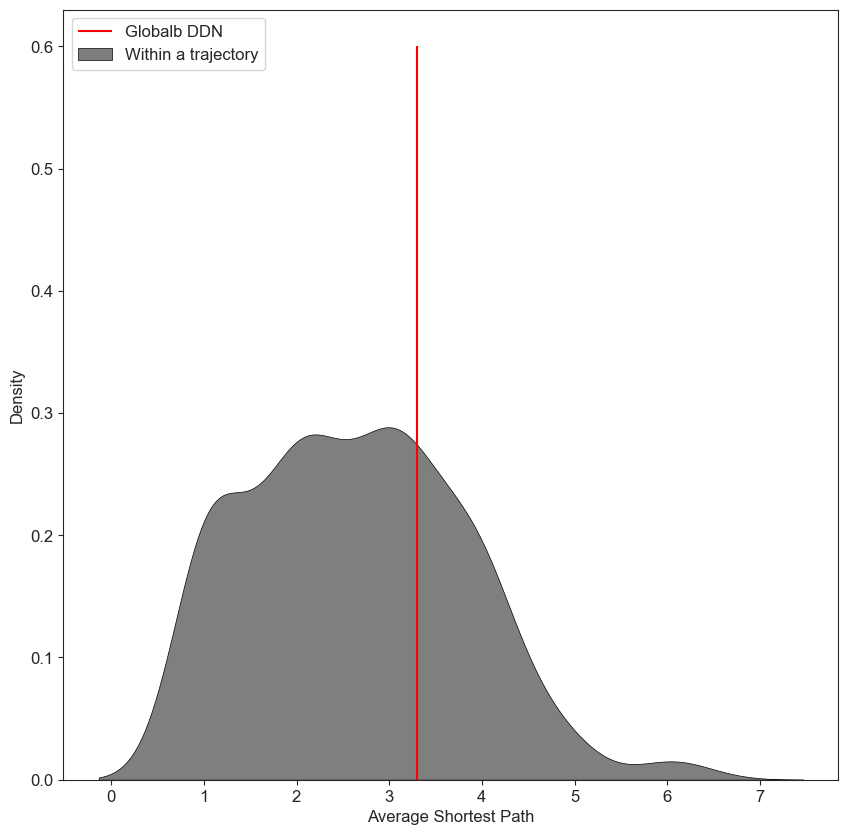

In [23]:
#Let's plot the distribution of all lcc z-scores

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(G_gene_icd_disp_significant_post_avg_sp,ymin=0,ymax=0.6,color='r',label='Globalb DDN')
sns.kdeplot(list(male_trajectories_dict_filtered_unique_DDN_avgsp.values()),color='k',lw=.5,alpha=.5,fill=True,label='Within a trajectory')

plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('Average Shortest Path',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/DDN_ShortestPath_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [28]:
# Append to your existing SourceData Excel
male_trajectories_dict_filtered_unique_DDN_avgsp_list = [i for i in male_trajectories_dict_filtered_unique_DDN_avgsp.values() if str(i)!='nan']
source_df = pd.DataFrame({
    "male_trajectories_dict_filtered_unique_DDN_avgsp": male_trajectories_dict_filtered_unique_DDN_avgsp_list
})

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(
        excel_path,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
    source_df.to_excel(
        writer,
        sheet_name="Fig3E",
        index=False
    )

In [29]:
len(male_trajectories_dict_filtered_unique_DDN_avgsp_list)

269

In [24]:

male_trajectories_dict_filtered_unique_DDN_avgsp_sort = {k: v for k, v in sorted(male_trajectories_dict_filtered_unique_DDN_avgsp.items(), key=lambda item: item[1],reverse=False)}




In [25]:
len([k for k,v in male_trajectories_dict_filtered_unique_DDN_avgsp_sort.items() if v<G_gene_icd_disp_significant_post_avg_sp])

188

In [30]:
len([k for k,v in male_trajectories_dict_filtered_unique_DDN_avgsp_sort.items() if v==1])

40

In [31]:
for trj in [k for k,v in male_trajectories_dict_filtered_unique_DDN_avgsp_sort.items() if v==1]:
    print(trj,male_trajectories_dict_filtered_unique[trj])

15_73 ['E10', 'E14', 'E16']
36 ['H90', 'H91']
51_181_282_362 ['C71', 'D43']
55 ['F11', 'F13', 'F19']
110 ['N18', 'D64']
121 ['E04', 'E05']
140 ['I20', 'I21', 'I25']
142 ['I35', 'I71']
144 ['I73', 'I74']
146 ['J03', 'J35', 'J36']
153 ['K40', 'K42', 'K43']
67 ['B20', 'B24']
72 ['N18', 'D64', 'N19']
90 ['H83', 'H91', 'H93']
91 ['I26', 'I80']
92 ['I42', 'I50']
99 ['K35', 'K37', 'K65']
173_360_400 ['C15', 'C16']
174_277 ['C18', 'C19', 'C20']
186 ['D13', 'K63', 'D12']
191 ['D68', 'I26', 'I80', 'I82']
209 ['G46', 'I63', 'I64', 'I66']
220 ['I35', 'I71', 'I72']
178_435 ['C43', 'D22']
184 ['C92', 'D46']
227 ['J34', 'J35', 'J36', 'M95']
233 ['K25', 'K26']
246 ['L97', 'L98']
256 ['L98', 'M86']
302 ['G30', 'F00']
322 ['I71', 'I72']
329 ['C44', 'L57', 'D23']
336 ['M07', 'L40']
340 ['M42', 'M47', 'M43', 'M48']
342 ['M81', 'M80', 'M85']
361 ['C25', 'C24']
367 ['C91', 'D80']
395 ['I26', 'I80', 'I82']
415 ['L98', 'M86', 'L97']
456 ['L97', 'L98', 'M86']


In [32]:
icd_1 = []
icd_2 = []
ji_list = []
for g_pair in G_gene_icd_disp_significant_post.edges():
    icd_1.append(g_pair[0])
    icd_2.append(g_pair[1])
    ji_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[g_pair[0]],allsources_icd_gene_dict_unified[g_pair[1]]))

mol_DDN_df = pd.DataFrame({'icd_1':icd_1,'icd_2':icd_2,'ji':ji_list})
mol_DDN_df.to_csv('output/mol_DDN_v2026_official.csv',index=False)


In [ ]:
#Let's calculate the genetic (largest connected component) z-score of the genese perturbed by each trajectory

In [36]:
#Let's import the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z


In [37]:
male_trajectories_dict_filtered_unique_distinct_zscore_dict={}
male_trajectories_dict_filtered_unique_agglomerated_zscore_dict={}

for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
    z_score_list=[]
    for dis in dislist:
        z_score_list.append(allsources_icd_gene_dict_unified_lcczscore[dis])
    male_trajectories_dict_filtered_unique_distinct_zscore_dict[agg_trj]=z_score_list
    
for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    male_trajectories_dict_filtered_unique_agglomerated_zscore_dict[agg_trj]=net_modularity(tot_genelsit,G_ppi)
    

In [38]:
with open('output/male_trajectories_dict_filtered_unique_distinct_zscore_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered_unique_distinct_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/male_trajectories_dict_filtered_unique_agglomerated_zscore_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(male_trajectories_dict_filtered_unique_agglomerated_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_46835/2328643788.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,


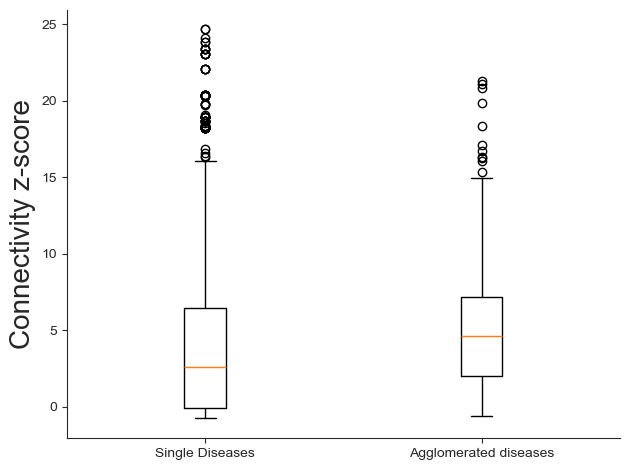

In [39]:
#Let's plot these boxplots

z_score_single_diseases=[]
z_score_agglomerated_diseases=[round(float(z),3) for z in male_trajectories_dict_filtered_unique_agglomerated_zscore_dict.values() if z!='nan']

for trj,z_scorelist in male_trajectories_dict_filtered_unique_distinct_zscore_dict.items():
    for z in z_scorelist:
        if z!='nan':
            z_score_single_diseases.append(round(float(z),3))
            

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Single Diseases','Agglomerated diseases']
plt.ylabel('Connectivity z-score',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[z_score_single_diseases,z_score_agglomerated_diseases]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

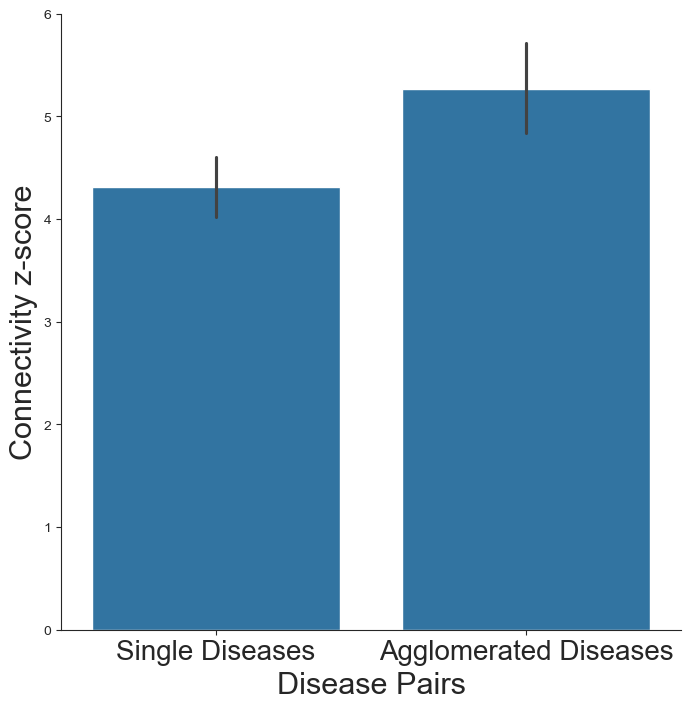

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

connectivity_df=pd.DataFrame()

status_list=[]
conn_list=[]

for i in z_score_single_diseases:
    status_list.append("Single Diseases")
    conn_list.append(i)
    
for i in z_score_agglomerated_diseases:
    status_list.append("Agglomerated Diseases")
    conn_list.append(i)

connectivity_df['Status']=status_list
connectivity_df['Connectivity']=conn_list

# Create a boxplot using seaborn
fig, ax = plt.subplots(figsize=(8, 8))
sns.set(style="white")

g=sns.barplot(x='Status', y='Connectivity', data=connectivity_df)
#g.set_yscale("log")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.xticks(fontsize=20)

plt.xlabel('Disease Pairs', fontsize=22)
plt.ylabel('Connectivity z-score', fontsize=22)
plt.savefig('Figures/Agglomerate_PPI_zscore_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [42]:

single_values = [v for v in z_score_single_diseases if pd.notna(v)]
agglomerated_values = [v for v in z_score_agglomerated_diseases if pd.notna(v)]

# -----------------------------
# 2. Build long-format dataframe
# -----------------------------
connectivity_df = pd.DataFrame({
    "Connectivity": single_values + agglomerated_values,
    "Status": (["Single Diseases"] * len(single_values)) +
              (["Agglomerated Diseases"] * len(agglomerated_values))
})

# Deterministic ordering
connectivity_df = connectivity_df.sort_values(["Status", "Connectivity"]).reset_index(drop=True)

# -----------------------------
# 3. Add metadata rows
# -----------------------------
connectivity_df["metadata"] = None

metadata_entries = [
    f"N_Single_Diseases: {len(single_values)}",
    f"N_Agglomerated_Diseases: {len(agglomerated_values)}",
    "Barplot shows mean Connectivity (default seaborn estimator=np.mean)",
    "Error bars = 95% confidence interval (seaborn default)"
]

metadata_df = pd.DataFrame({
    "Connectivity": [None]*len(metadata_entries),
    "Status": [None]*len(metadata_entries),
    "metadata": metadata_entries
})

source_df = pd.concat([connectivity_df, metadata_df], ignore_index=True)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig3F", index=False)

print(f"Source data saved to {excel_path}")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_46835/3013162604.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  source_df = pd.concat([connectivity_df, metadata_df], ignore_index=True)


Source data saved to output/SourceData.xlsx


In [41]:

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(z_score_single_diseases,z_score_agglomerated_diseases)
p_value

0.003034294411016652

In [43]:
#Let's create a network now out of this condensed unique trajectories
#We are going to focus on those trajectories that have less than 13 elements because we have shown that those are the ones
#that have the highest coherence with the genetic basis
G_elma_icd_male = nx.Graph() 

for dislist in list(male_trajectories_dict_filtered_unique.values()):
    if len(dislist)<13:
        for dis1 in dislist:
            for dis2 in dislist:
                if dis1!=dis2:
                    G_elma_icd_male.add_edge(dis1, dis2)
                
print(G_elma_icd_male.number_of_nodes())
print(G_elma_icd_male.number_of_edges())

426
2109


In [46]:
G_elma_icd_male_df = nx.to_pandas_edgelist(G_elma_icd_male,'Dis A', 'Dis B')
G_elma_icd_male_df.to_csv('output/G_elma_icd_male_df_v2026_official.tsv', sep = '\t')


In [49]:
from cartoGRAPHs import *
import random 
from sklearn.decomposition import PCA
from sklearn import preprocessing
import json
import matplotlib.colors as mcolors
import colorsys
import pickle as pk

In [50]:
icd_cat = set([str(n[0]) for n in G_elma_icd_male.nodes()])

In [51]:
icd_code_comm = {}
for icd in icd_cat:
    nodelist = []
    for node in G_elma_icd_male.nodes():
        if icd in node:
            nodelist.append(node)
    icd_code_comm[icd] = nodelist

In [52]:
# creating a feature dataframe based on community
feature_df = pd.DataFrame()
    
for g in G_elma_icd_male.nodes():
    feature_list=[]
    for icd, nodelist in icd_code_comm.items():
        if g in nodelist:
            feature_list.append(1)
        else:
            feature_list.append(0)
    feature_df[g]=feature_list


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_33382/2799973441.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_33382/2799973441.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_33382/2799973441.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [53]:
feature_df_T=feature_df.T

In [55]:
r = 0.9
alpha = 1.0

A = nx.adjacency_matrix(G_elma_icd_male, nodelist=list(G_elma_icd_male.nodes()))
DM_m = rnd_walk_matrix2(A, r, alpha, len(G_elma_icd_male.nodes()))
FM_structural = pd.DataFrame(DM_m)
FM_structural.sum(axis=1) # axis=1 for columns i.e. features = sum 1
FM_structural.index=list(G_elma_icd_male.nodes())
FM_structural.columns=list(G_elma_icd_male.nodes())
FM_structural

,K35,K37,K56,K65,A04,F50,J10,H73,K92,A41,...,J62,L84,G43,C80,D31,D36,D75,E53,G56,M72
K35,9.018292e-01,3.086145e-02,1.052425e-02,1.349014e-02,3.370013e-07,1.773691e-08,1.773691e-08,1.038025e-08,1.038025e-07,2.791619e-04,...,2.571963e-09,1.141390e-09,4.728251e-10,4.432403e-08,5.804280e-09,2.144744e-06,8.991132e-10,7.911758e-09,4.583236e-12,4.583236e-12
K37,3.086145e-02,9.018292e-01,1.052425e-02,1.349014e-02,3.370013e-07,1.773691e-08,1.773691e-08,1.038025e-08,1.038025e-07,2.791619e-04,...,2.571963e-09,1.141390e-09,4.728251e-10,4.432403e-08,5.804280e-09,2.144744e-06,8.991132e-10,7.911758e-09,4.583236e-12,4.583236e-12
K56,3.157275e-02,3.157275e-02,9.016516e-01,1.395823e-02,1.030204e-06,5.422125e-08,5.422125e-08,8.773680e-07,8.773680e-06,2.889352e-04,...,1.482641e-07,6.065435e-09,2.555197e-08,1.661594e-07,6.316869e-09,1.835950e-04,7.467993e-08,1.262945e-08,3.216963e-10,3.216963e-10
K65,3.147699e-02,3.147699e-02,1.085640e-02,9.019764e-01,2.200248e-05,1.158025e-06,1.158025e-06,1.999971e-08,1.999971e-07,1.866523e-02,...,5.871965e-08,7.251648e-08,1.212075e-08,2.870025e-06,3.878431e-07,2.331520e-06,2.755601e-09,5.255394e-07,5.992409e-11,5.992409e-11
A04,2.022008e-06,2.022008e-06,2.060408e-06,5.657782e-05,9.013572e-01,4.743986e-02,4.743986e-02,2.761038e-10,2.761038e-09,3.181526e-06,...,1.032997e-06,1.025382e-03,1.867780e-06,2.372830e-06,9.108078e-07,1.820309e-04,2.438608e-06,6.610861e-05,8.296899e-10,8.296899e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
D36,2.859658e-06,2.859658e-06,8.159780e-05,1.332297e-06,4.045131e-05,2.129016e-06,2.129016e-06,6.897808e-09,6.897808e-08,1.770498e-06,...,3.018664e-08,4.773116e-08,9.902552e-09,7.263042e-06,2.672653e-08,9.008240e-01,7.503097e-10,9.293312e-09,7.516128e-12,7.516128e-12
D75,1.198818e-09,1.198818e-09,3.319108e-08,1.574629e-09,5.419130e-07,2.852174e-08,2.852174e-08,7.054655e-12,7.054655e-11,1.234092e-08,...,2.314537e-10,4.681357e-06,1.815789e-09,8.775683e-10,1.821206e-11,7.503097e-10,9.014206e-01,5.718860e-10,1.029612e-11,1.029612e-11
E53,2.109802e-08,2.109802e-08,1.122618e-08,6.006164e-07,2.938161e-05,1.546400e-06,1.546400e-06,7.217490e-11,7.217490e-10,3.985281e-08,...,8.203198e-08,8.341005e-08,8.073724e-07,6.478784e-07,9.030693e-05,1.858662e-08,1.143772e-09,9.006934e-01,1.338111e-08,1.338111e-08
G56,3.055491e-12,3.055491e-12,7.148807e-11,1.712117e-11,9.218777e-11,4.851988e-12,4.851988e-12,2.501337e-13,2.501337e-12,7.640737e-11,...,6.929447e-11,7.062779e-12,2.395613e-06,6.212415e-11,2.736725e-11,3.758064e-12,5.148060e-12,3.345279e-09,9.026399e-01,4.549700e-02


In [56]:
scalar_val = 0.55
layout_method = 'modulated-scal'+str(scalar_val)
DF_structural = FM_structural
DF_functional = feature_df
DF_merge = feature_modulation(DF_structural,DF_functional, scalar_val)

n_n = 10
spr = 2
md = 1.5
metr2D = 'cosine'

posG2D_modulated = layout_portrait_umap(G_elma_icd_male,
                                   DF_merge,
                                   2,
                                   n_neighbors=n_n, 
                                   spread=spr, 
                                   min_dist=md, 
                                   metric=metr2D
                                  )

posG2D_new = posG2D_modulated

/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [57]:
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1

edge_opacity = 0.5
edge_width = 0.1
edge_color = '#A1A1A1' #'#6C6C6C' #'#d3d3d3'

In [58]:
with open('output/icd_cat_color_mapping.pickle', 'rb') as handle:
    icd_cat_color_mapping = pk.load(handle)

In [59]:
def draw_node_degree(G, scalef):
    '''
    Calculate the node degree from graph positions (dict).
    Return list of radii for each node (2D). 
    '''
    
    l_size = {}
    for node in G.nodes():
        k = nx.degree(G, node)
        if k > 0:
            R = k*scalef +0.25 #math.log(k) * scalef + 0.25
        else: 
            R = 0.1
        l_size[node] = R
        
    return l_size

scale_factor = 15 #0.15
d_size = draw_node_degree(G_elma_icd_male, scale_factor)
l_size = [d_size[n] for n in posG2D_new.keys()]

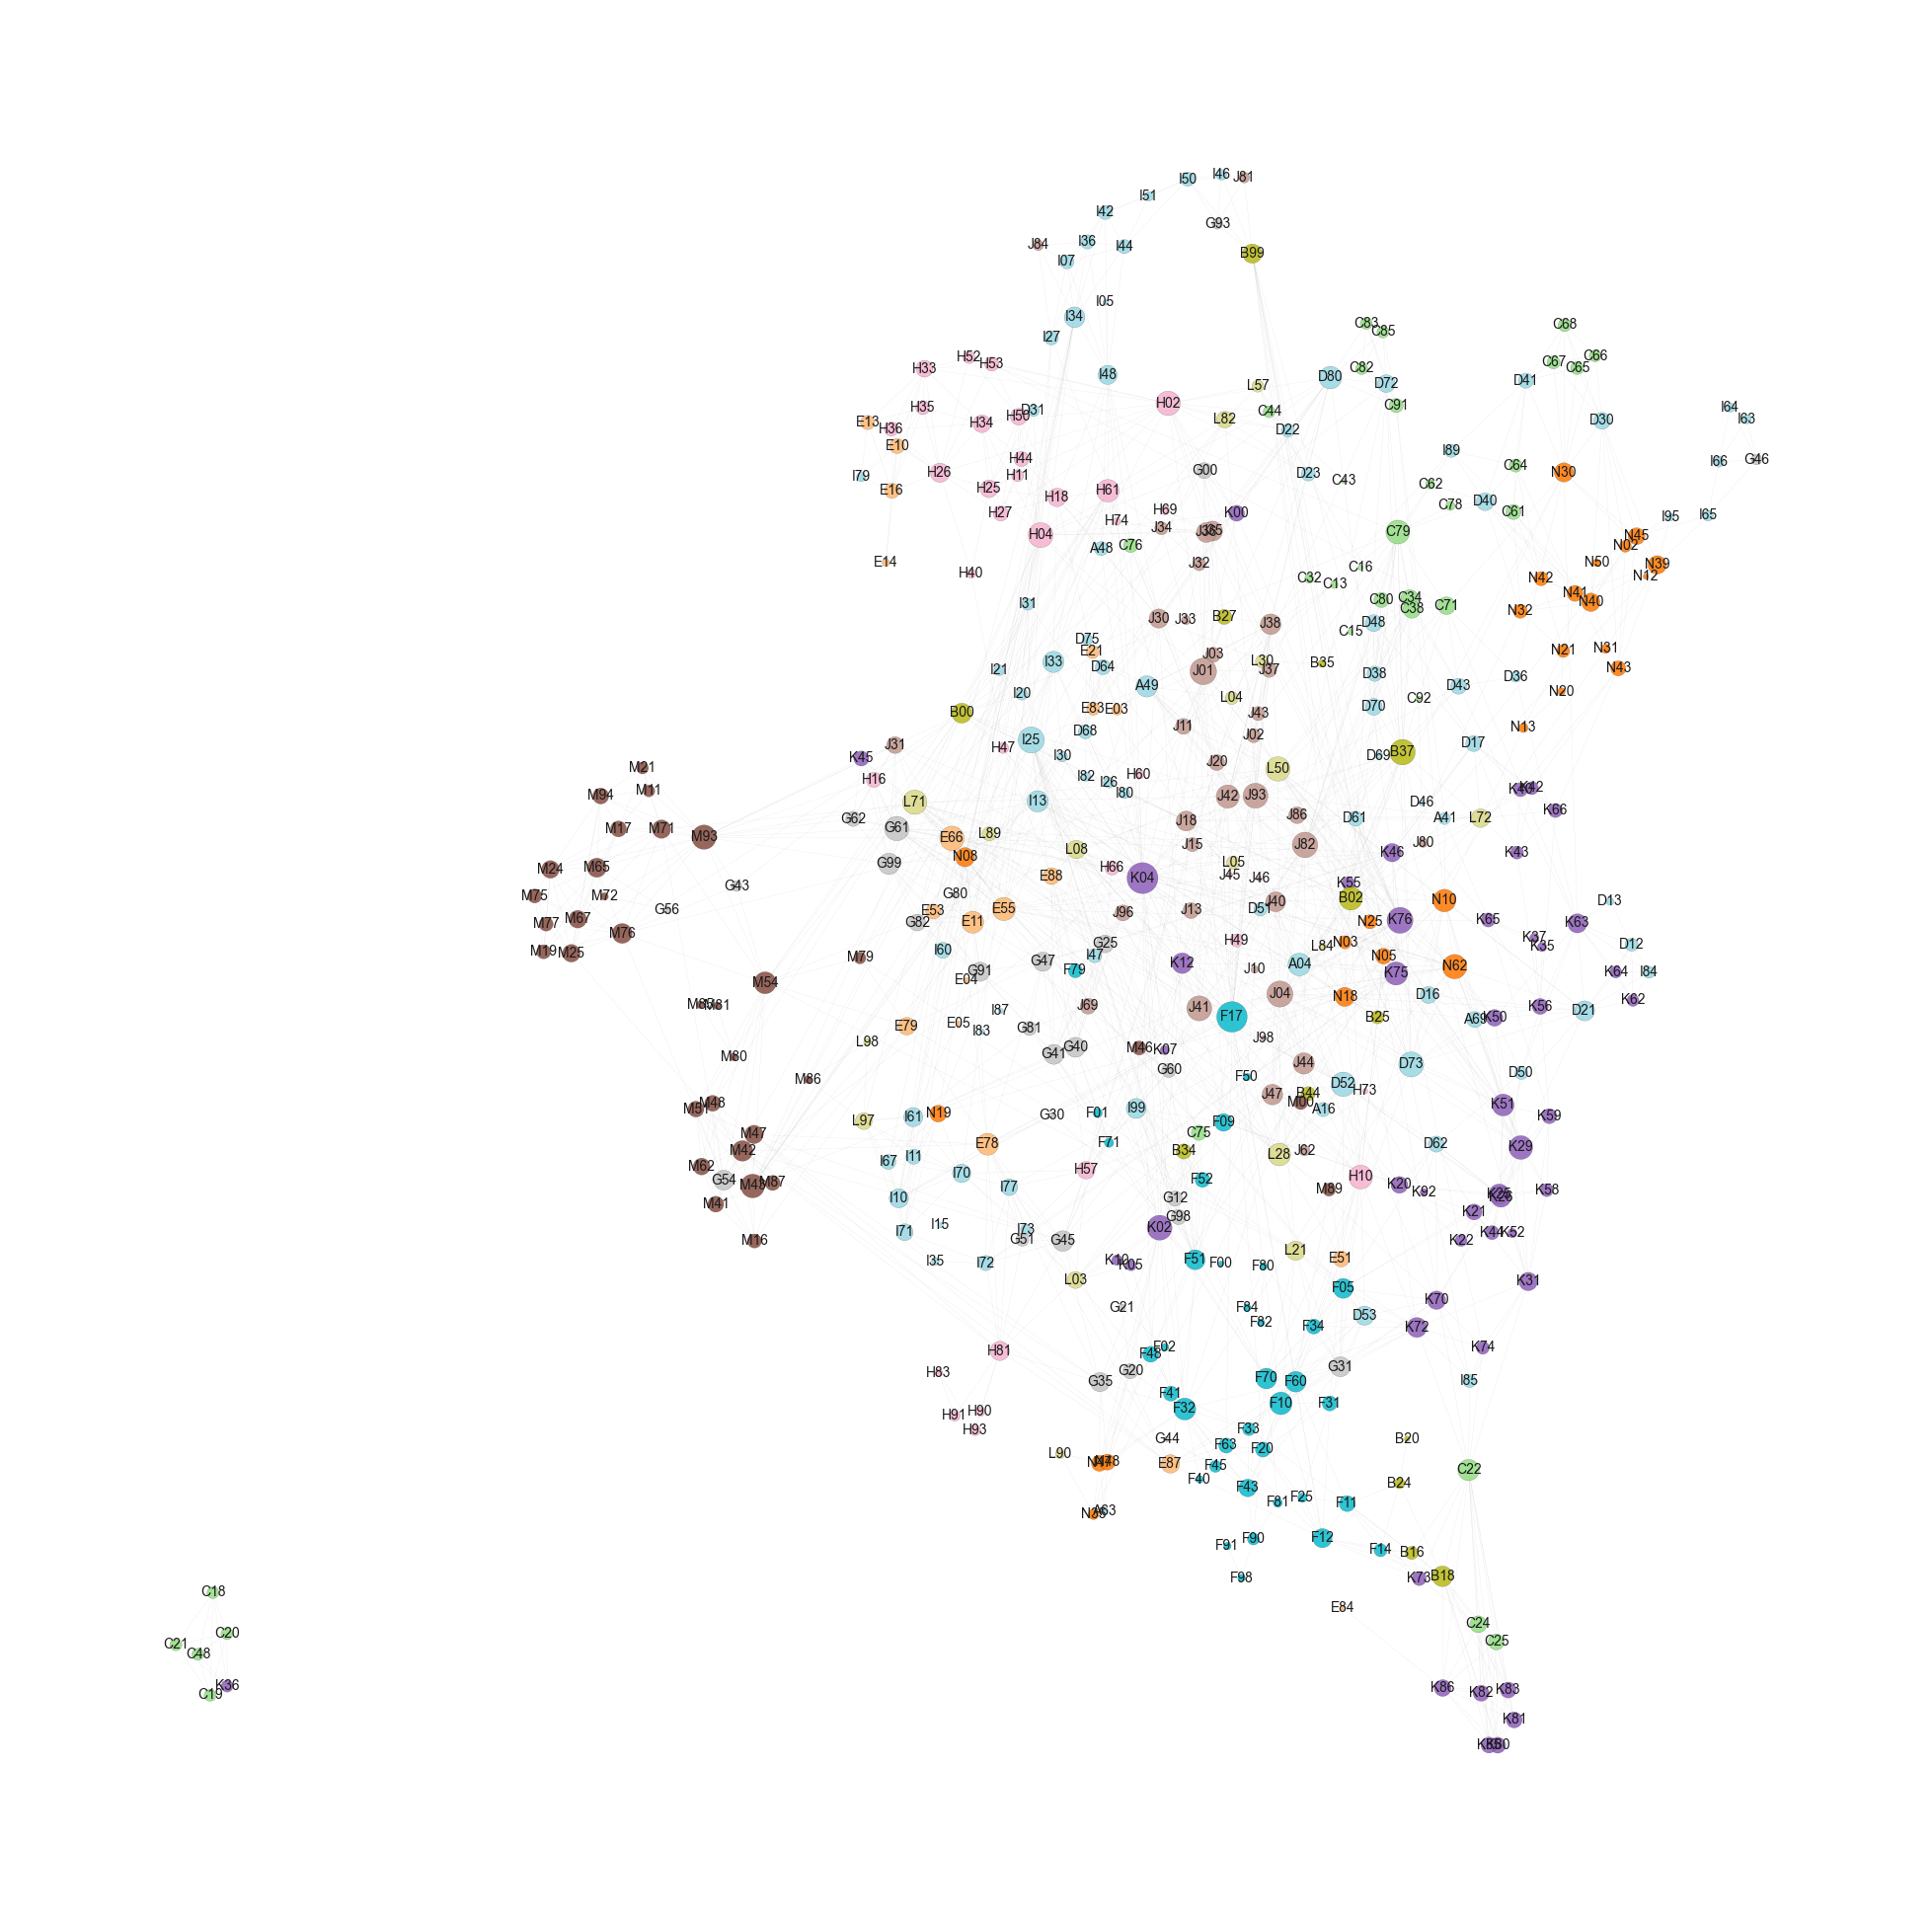

In [60]:
color_list = []
for node in posG2D_new.keys():
    color_list.append(icd_cat_color_mapping[node[0]])


plt.figure(figsize=(25,25))
nx.draw_networkx_nodes(G_elma_icd_male, 
                       posG2D_new,
                       edgecolors = node_edge_col, 
                       linewidths = node_linewidth, 
                       node_color = color_list, 
                       node_size = l_size, 
                       alpha = opacity_nodes)

nx.draw_networkx_edges(G_elma_icd_male, posG2D_new,  width = edge_width, edge_color = edge_color, alpha = edge_opacity)
plt.box(False)
nx.draw_networkx_labels(G_elma_icd_male,pos=posG2D_new,font_size=10)
plt.savefig('Figures/Fig3H_v2026.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()



In [48]:

G_elma_icd_male_df = pd.read_csv('output/G_elma_icd_male_df_v2026_official.tsv', sep="\t",index_col=0)
G_elma_icd_male_nx = nx.from_pandas_edgelist(G_elma_icd_male_df, 'Dis A', 'Dis B')

In [47]:
G_elma_icd_male_degree=dict(nx.degree(G_elma_icd_male))
dict(sorted(G_elma_icd_male_degree.items(), key=lambda item: item[1],reverse=True))

{'H10': 38,
 'K04': 37,
 'F17': 35,
 'I13': 35,
 'D52': 33,
 'J01': 30,
 'N10': 27,
 'E78': 27,
 'I25': 27,
 'J41': 27,
 'E11': 26,
 'K76': 25,
 'K08': 25,
 'J04': 25,
 'B37': 25,
 'K02': 24,
 'E13': 24,
 'N62': 24,
 'J82': 24,
 'D73': 24,
 'H04': 23,
 'I10': 23,
 'C79': 22,
 'E61': 22,
 'H02': 22,
 'M43': 22,
 'J93': 22,
 'M93': 22,
 'L71': 22,
 'L50': 21,
 'J42': 21,
 'E66': 21,
 'L03': 21,
 'J39': 21,
 'K29': 21,
 'F13': 21,
 'H61': 20,
 'F10': 20,
 'H81': 20,
 'K20': 20,
 'I77': 20,
 'K75': 20,
 'G61': 20,
 'B02': 20,
 'D80': 19,
 'F32': 19,
 'M54': 19,
 'H25': 19,
 'H26': 19,
 'E55': 19,
 'I99': 19,
 'L28': 19,
 'K12': 18,
 'F60': 18,
 'B18': 18,
 'I50': 18,
 'K51': 18,
 'F34': 18,
 'N05': 18,
 'N30': 18,
 'H16': 18,
 'A04': 17,
 'N48': 17,
 'C22': 17,
 'J44': 17,
 'I72': 17,
 'M84': 17,
 'A49': 16,
 'J35': 16,
 'J36': 16,
 'F12': 16,
 'G31': 16,
 'M76': 16,
 'F51': 16,
 'B00': 16,
 'J47': 16,
 'I33': 16,
 'H57': 16,
 'A08': 15,
 'F70': 15,
 'G41': 15,
 'G40': 15,
 'J18': 15,
 'K2

In [48]:
for e in G_elma_icd_male.edges():
    if 'K04' in e:
        print(e)

('J11', 'K04')
('J30', 'K04')
('J42', 'K04')
('F17', 'K04')
('K02', 'K04')
('H60', 'K04')
('H66', 'K04')
('K04', 'K08')
('K04', 'K12')
('K04', 'K07')
('K04', 'K09')
('K04', 'F32')
('K04', 'F48')
('K04', 'B37')
('K04', 'F51')
('K04', 'D52')
('K04', 'J41')
('K04', 'L71')
('K04', 'J13')
('K04', 'J39')
('K04', 'L08')
('K04', 'N62')
('K04', 'I25')
('K04', 'I13')
('K04', 'I30')
('K04', 'I33')
('K04', 'I20')
('K04', 'B00')
('K04', 'J04')
('K04', 'D51')
('K04', 'H49')
('K04', 'J82')
('K04', 'I48')
('K04', 'A48')
('K04', 'C76')
('K04', 'H18')
('K04', 'H61')


In [49]:
for e in G_elma_icd_male.edges():
    if 'F17' in e:
        print(e)

('J38', 'F17')
('J20', 'F17')
('J42', 'F17')
('J01', 'F17')
('K76', 'F17')
('E66', 'F17')
('E78', 'F17')
('F17', 'I10')
('F17', 'E87')
('F17', 'F10')
('F17', 'F12')
('F17', 'F20')
('F17', 'F60')
('F17', 'F63')
('F17', 'J93')
('F17', 'G45')
('F17', 'J15')
('F17', 'L05')
('F17', 'D52')
('F17', 'J41')
('F17', 'L71')
('F17', 'J13')
('F17', 'J39')
('F17', 'K04')
('F17', 'K08')
('F17', 'K12')
('F17', 'L08')
('F17', 'N62')
('F17', 'J37')
('F17', 'J43')
('F17', 'J02')
('F17', 'J04')
('F17', 'D51')
('F17', 'H49')
('F17', 'J82')


In [50]:
#Extract degrees from the DDN
degrees_DDN = [x[1] for x in  nx.degree(G_elma_icd_male)]
#Get the unique PPI degree steps

degrees_DDN_unique = list(set(degrees_DDN))
degrees_DDN_unique.sort()

#degree for x axis (sorted from small to biggest)
degreesDDN = []

#Normal distribution (i.e. P(k = x))
degreeDistributionDDN = []
degreeDistributionDDNcount = []

for degree in degrees_DDN_unique:
    degreesDDN.append(degree)
    degreeDistributionDDN.append(degrees_DDN.count(degree)/float(len(degrees_DDN)))
    degreeDistributionDDNcount.append(degrees_DDN.count(degree))

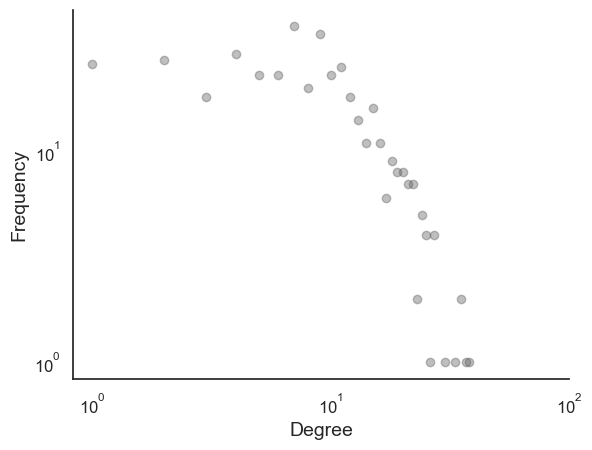

In [51]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import figure
from matplotlib.ticker import MaxNLocator

#Let's plot the Degree distribution of the EEN
fig1, ax1 = plt.subplots()
plt.scatter(degreesDDN, degreeDistributionDDNcount, c='#5F5F5F', alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
ax1.set_xticks([1,10, 100])

plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
plt.savefig('Figures/EpidemiologicalcNetwork_DegreeDistribution_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 

plt.show()
plt.close()

In [61]:

genetic_edges = []
tot_edges = []

for e in G_gene_icd_disp_significant_post.edges():
    if e[0] in G_elma_icd_male_nx.nodes() and e[1] in G_elma_icd_male_nx.nodes():
        genetic_edges.append(e)
        tot_edges.append(e)
        
for e in G_elma_icd_male_nx.edges():
    if e not in tot_edges:
        tot_edges.append(e)

In [62]:
male_shared_gen_epi_edges = []

for e in genetic_edges:
    if (e[0],e[1]) in G_elma_icd_male_nx.edges() or (e[1],e[0]) in G_elma_icd_male_nx.edges():
        male_shared_gen_epi_edges.append(e)

for e in G_elma_icd_male_nx.edges():
    if (e[0],e[1]) in genetic_edges or (e[1],e[0]) in genetic_edges:
        if e not in male_shared_gen_epi_edges:
            male_shared_gen_epi_edges.append(e)
len(male_shared_gen_epi_edges)

277

In [53]:
trj_with_genetic_basis = []
trj_with_genetic_basis_dict = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    pairwise_dislist = it.permutations(dislist,2)   #I want to include both orders
    intersection_dislist = set(male_shared_gen_epi_edges) & set(pairwise_dislist)
    trj_with_genetic_basis_dict[trj] = len(intersection_dislist)
    if len(intersection_dislist)>0:
        trj_with_genetic_basis.append(trj)
trj_with_genetic_basis_dict = dict(sorted(trj_with_genetic_basis_dict.items(), key=lambda item: item[1],reverse=True))

In [71]:
for trj in trj_with_genetic_basis:
    if "K21" in male_trajectories_dict_filtered_unique[trj]:
        print(trj,male_trajectories_dict_filtered_unique[trj])

39 ['K21', 'K29', 'K44', 'K52']
151 ['K20', 'K21', 'K25', 'K26', 'D62']
152 ['K21', 'K25', 'K26', 'K31']
232 ['K20', 'K22', 'K21', 'K25', 'K26', 'K44']


In [54]:
trj_with_genetic_basis_dict

{'77': 15,
 '79': 13,
 '405': 13,
 '408': 13,
 '78': 10,
 '10': 9,
 '108': 9,
 '123': 9,
 '232': 9,
 '57': 8,
 '191': 8,
 '366': 8,
 '436': 8,
 '386': 7,
 '216': 6,
 '270': 6,
 '415': 6,
 '445': 6,
 '456': 6,
 '140': 5,
 '153': 5,
 '157_240': 5,
 '217': 5,
 '220': 5,
 '235': 5,
 '329': 5,
 '378': 5,
 '414': 5,
 '15_73': 4,
 '55': 4,
 '72': 4,
 '74': 4,
 '98': 4,
 '118': 4,
 '318': 4,
 '389': 4,
 '395': 4,
 '450': 4,
 '12': 3,
 '13': 3,
 '18': 3,
 '23': 3,
 '147': 3,
 '151': 3,
 '156': 3,
 '189': 3,
 '221': 3,
 '370': 3,
 '376': 3,
 '390': 3,
 '392': 3,
 '424': 3,
 '441': 3,
 '443': 3,
 '446': 3,
 '459': 3,
 '1': 2,
 '22': 2,
 '34': 2,
 '39': 2,
 '54': 2,
 '67': 2,
 '68': 2,
 '91': 2,
 '94': 2,
 '99': 2,
 '103': 2,
 '110': 2,
 '121': 2,
 '122_194': 2,
 '125': 2,
 '133': 2,
 '139': 2,
 '142': 2,
 '146': 2,
 '167': 2,
 '168': 2,
 '173_360_400': 2,
 '178_435': 2,
 '186': 2,
 '205': 2,
 '212': 2,
 '218': 2,
 '227': 2,
 '228': 2,
 '239': 2,
 '246': 2,
 '256': 2,
 '260_347_460': 2,
 '261': 2,

In [55]:
len(trj_with_genetic_basis)

158

In [57]:
len(trj_with_genetic_basis_dict)

329

In [49]:
icd_1 = []
icd_2 = []
ji_list = []

for g_pair in G_elma_icd_male_nx.edges():
    icd_1.append(g_pair[0])
    icd_2.append(g_pair[1])
    ji_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[g_pair[0]],allsources_icd_gene_dict_unified[g_pair[1]]))

mol_DDN_df = pd.DataFrame({'icd_1':icd_1,'icd_2':icd_2,'ji':ji_list})
mol_DDN_df.to_csv('output/mol_male_DDN_v2026_official.csv',index=False)


# Females

In [25]:
female_trajectories_df_copy=pd.DataFrame()
female_trajectories_df_copy['Community ID'] = female_trajectories_df['Community ID']

new_members_of_com_list=[]
for i in female_trajectories_df['Members'].tolist():
    new_i=i.replace("__","-")
    new_new_i=new_i.replace(" ","")
    new_members_of_com_list.append(new_new_i)
female_trajectories_df_copy['Members']=new_members_of_com_list

female_trajectories_df_copy.head()

,Community ID,Members
0,1,"I88-0-9,K56-0-9,K59-0-9,K60-0-9,K56-10-19"
1,2,"A08-0-9,A38-10-19,B01-10-19,H61-10-19,J38-10-19"
2,3,"A38-0-9,B97-0-9,E45-0-9,G47-0-9,H04-0-9,J10-0-..."
3,4,"A41-0-9,C91-0-9,C91-10-19"
4,5,"B00-0-9,B99-0-9,J05-0-9,J31-0-9,J40-0-9,K52-0-..."


In [26]:

female_trajectories_dict={}
for i,v in female_trajectories_df_copy.iterrows():
    dis_list=[]
    for dis in v['Members'].split(','):
        clean_dis=dis.split("-")[0]
        if clean_dis in allsources_icd_gene_dict_unified.keys():
            dis_list.append(dis)
    female_trajectories_dict[v['Community ID']]=dis_list

#Now, let's remove all the trajectories that are obvious (same disease)
female_trajectories_dict_filtered={}
for trj,dislist in female_trajectories_dict.items():
    new_dislist=[]
    if len(dislist)>1:
        for dis in dislist:
            new_dis=dis[:3]
            if new_dis not in new_dislist:
                if new_dis in allsources_icd_gene_dict_unified.keys():
                    new_dislist.append(new_dis)
    if len(new_dislist)>1:
        female_trajectories_dict_filtered[trj]=new_dislist

print(len(female_trajectories_dict_filtered))


354


In [16]:
#Some of these disease-trajectories contain the same diseases, for this reason, now we will focus only on the
#unique disease-trajectories

In [28]:
female_trajectories_dict_filtered_unique=agglomerate_dict(female_trajectories_dict_filtered)

In [29]:
len(female_trajectories_dict_filtered_unique)

305

In [30]:
len(set([x for xs in list(female_trajectories_dict_filtered_unique.values()) for x in xs]))

490

In [62]:
with open('output/female_trajectories_dict_filtered_v2026_official.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/female_trajectories_dict_filtered_unique_v2026_official.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered_unique, handle, protocol=pk.HIGHEST_PROTOCOL)

In [63]:
with open('output/female_trajectories_dict_filtered_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered = pk.load(handle)

with open('output/female_trajectories_dict_filtered_unique_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique = pk.load(handle)

In [64]:
female_trajectories_dict_filtered_unique_agglomerated_genes={}

for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    female_trajectories_dict_filtered_unique_agglomerated_genes[agg_trj]=tot_genelsit

In [65]:
with open('output/female_trajectories_dict_filtered_unique_agglomerated_genes_v2026_official.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered_unique_agglomerated_genes, handle, protocol=pk.HIGHEST_PROTOCOL)

In [66]:
with open('output/female_trajectories_dict_filtered_unique_agglomerated_genes_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique_agglomerated_genes = pk.load(handle)

In [31]:
female_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in female_trajectories_dict_filtered_unique.items():
    overlap_list=[]
    for dis1 in dislist:
        for dis2 in dislist:
            if dis1!=dis2:
                overlap_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[dis1],allsources_icd_gene_dict_unified[dis2]))
    if len(overlap_list)>0:
        female_trajectories_dict_filtered_unique_avg_overlap[com]=sum(overlap_list)/len(overlap_list)
  

In [32]:
#Let's compare against a null distribution

rd_female_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in female_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(list(allsources_icd_gene_dict_unified.keys()),len(dislist))
    for i in range(1000):
        for rd_dis1 in random_dislist:
            for rd_dis2 in random_dislist:
                if rd_dis1!=rd_dis2:
                    rd_overlap_distribution.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[rd_dis1],allsources_icd_gene_dict_unified[rd_dis2])))
                
    rd_female_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_56358/1592818400.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


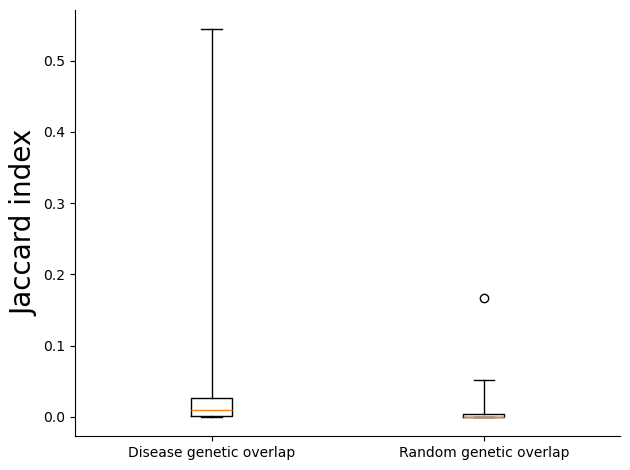

In [33]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_female_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.mean(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(female_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()
#plt.savefig('Figures/FemaleTrajectories_JI_Random.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [34]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(female_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

3.3423364338077343e-13

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_56358/2422133424.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


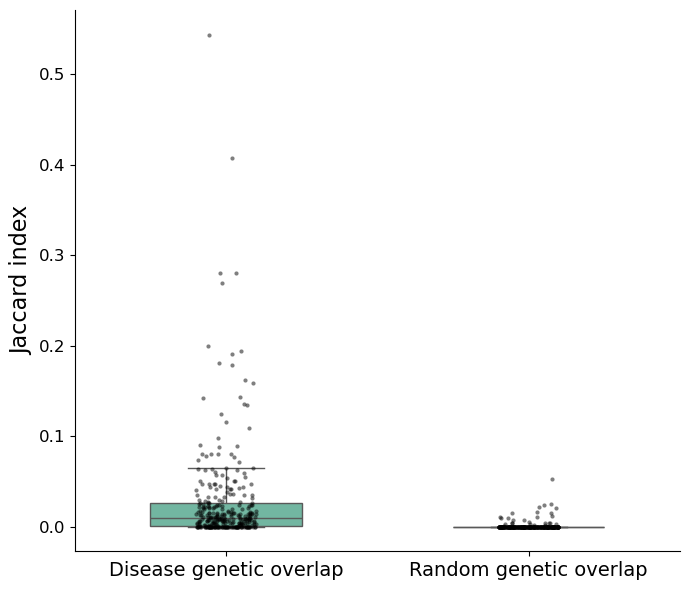

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure fonts remain editable in Illustrator/Inkscape
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

# Prepare data
rd_ov_list = [np.median(ov_distribution) for ov_distribution in rd_female_trajectories_dict_filtered_unique_avg_overlap.values()]

df_plot = pd.DataFrame({
    "value": list(female_trajectories_dict_filtered_unique_avg_overlap.values()) + rd_ov_list,
    "group": (["Disease genetic overlap"] * len(female_trajectories_dict_filtered_unique_avg_overlap)) +
             (["Random genetic overlap"] * len(rd_ov_list))
})

# Create figure
plt.figure(figsize=(7,6))
sns.boxplot(
    data=df_plot,
    x="group",
    y="value",
    showfliers=False,   # hide extreme outliers
    width=0.5,
    palette="Set2"
)
sns.stripplot(
    data=df_plot,
    x="group",
    y="value",
    color="black",
    alpha=0.5,
    jitter=True,
    size=3
)

# Labels
plt.ylabel("Jaccard index", fontsize=16)
plt.xlabel("", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)

sns.despine()
plt.tight_layout()

# Save in vector formats (text editable)
plt.savefig("Figures/FemaleTrajectories_JI_Random_v2026_official.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("Figures/FemaleTrajectories_JI_Random_v2026_official.svg", format="svg", dpi=300, bbox_inches="tight")

plt.show()

In [36]:
tot_filtered_dis_list=[]
for dislist in female_trajectories_dict_filtered_unique.values():
    for dis in dislist:
        if dis not in tot_filtered_dis_list:
            tot_filtered_dis_list.append(dis)
            
print(len(tot_filtered_dis_list))

490


In [37]:
#Let's compare against a null distribution, where we sample only among the 510 diseases present in the disease trajectories

rd_female_trajectories_dict_filtered_unique_avg_overlap={}
for com,dislist in female_trajectories_dict_filtered_unique.items():
    rd_overlap_distribution=[]
    random_dislist=rd.sample(tot_filtered_dis_list,len(dislist))
    for i in range(1000):
        for rd_dis1 in random_dislist:
            for rd_dis2 in random_dislist:
                if rd_dis1!=rd_dis2:
                    rd_overlap_distribution.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[rd_dis1],allsources_icd_gene_dict_unified[rd_dis2])))
                
    rd_female_trajectories_dict_filtered_unique_avg_overlap[com]=rd_overlap_distribution
    
    

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_56358/3303169198.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist


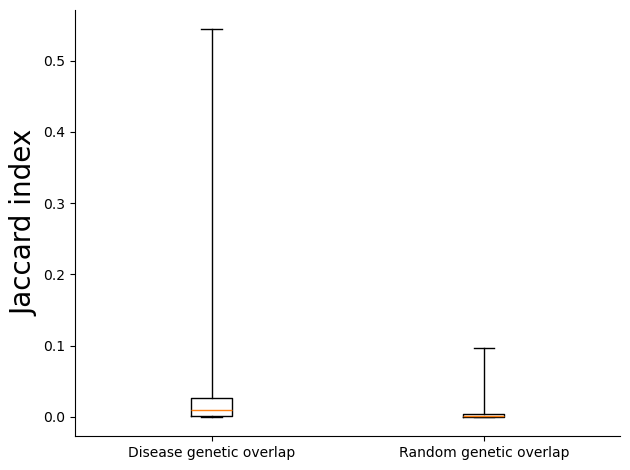

In [38]:
#Let's plot these boxplots

rd_ov_list=[]
for com,ov_distribution in rd_female_trajectories_dict_filtered_unique_avg_overlap.items():
    rd_ov_list.append(np.mean(ov_distribution))

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Disease genetic overlap','Random genetic overlap']
plt.ylabel('Jaccard index',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[list(female_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,whis=25,   #we are including all data points...like almost no outliers exist
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

In [39]:
#T-test
#Let's check now by performing a T-test

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(list(female_trajectories_dict_filtered_unique_avg_overlap.values()),rd_ov_list)
p_value

2.480315979498972e-13

In [78]:
#Now, we will look more in the details of this shared relationships, computing the pairs/triplets and so on
#and comparing accordingly each community against its corresponding random distribution
dis_list=list(allsources_icd_gene_dict_unified.keys())
pair_diseases_list=list(it.combinations(dis_list,2))

In [79]:
jaccard_pairs_reference_list=[]

for dispair in pair_diseases_list:
    jaccard_pairs_reference_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
    
print(len(jaccard_pairs_reference_list))

292995


In [80]:
jaccard_pairs_from_n_plets_elma_list_dict={}
jaccard_pairs_from_n_plets_elma_list_pval_dict={}
jaccard_pairs_from_n_plets_elma_list_fdr_dict={}

for s in set([len(v) for v in female_trajectories_dict_filtered_unique.values()]):

    jaccard_pairs_from_n_plets_elma_list=[]
    selected_disnlets=[]
    for trj,dislist in female_trajectories_dict_filtered_unique.items():
        if len(dislist)==s:
            if dislist not in selected_disnlets:
                selected_disnlets.append(dislist)

    selected_dispair_fromnplets=[]
    for disqua in selected_disnlets:
        jo_list=[]
        dispairdisn=list(it.combinations(disqua,2))          
        for dispair in dispairdisn:
            if dispair not in selected_dispair_fromnplets:
                selected_dispair_fromnplets.append(dispair)

    for dispair in selected_dispair_fromnplets:
        try:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
        except:
            jaccard_pairs_from_n_plets_elma_list.append(float(overlap_jaccard(allsources_icd_gene_dict_unified[dispair[0]],allsources_icd_gene_dict_unified[dispair[1]])))
            
    jaccard_pairs_from_n_plets_elma_list_dict[s]=jaccard_pairs_from_n_plets_elma_list

    t_value,p_value=stats.ttest_ind(jaccard_pairs_reference_list,jaccard_pairs_from_n_plets_elma_list)
    jaccard_pairs_from_n_plets_elma_list_pval_dict[s] = p_value

adj_pval=fdr_adjustment(list(jaccard_pairs_from_n_plets_elma_list_pval_dict.values()),0.05)
pair_list=list(jaccard_pairs_from_n_plets_elma_list_pval_dict.keys())
for i in range(len(adj_pval)):
    jaccard_pairs_from_n_plets_elma_list_fdr_dict[pair_list[i]]=adj_pval[i]


In [81]:
with open('output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_female_v2026_official.pickle', 'wb') as handle:
    pk.dump(jaccard_pairs_from_n_plets_elma_list_fdr_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [82]:
jaccard_pairs_from_n_plets_elma_list_fdr_dict

{2: 1.620427237461155e-36,
 3: 3.1835749156614554e-168,
 4: 4.2307506385740493e-47,
 5: 1.7505697558672074e-54,
 6: 1.019150403259093e-09,
 7: 2.6411570264576072e-67,
 8: 0.09884842752003352,
 9: 0.13724198001003945,
 10: 0.09884842752003352,
 11: 1.2023328802556216e-06,
 12: 0.282452891686023,
 13: 5.64153069660402e-09,
 40: 0.476173430650496,
 15: 8.829573249823308e-28,
 48: 0.10014847244975986,
 22: 4.11874255072913e-08,
 55: 0.11260319733200834,
 28: 0.003708883440104777}

In [83]:
import csv
import os

data = {2: 1.620427237461155e-36,
 3: 3.1835749156614554e-168,
 4: 4.2307506385740493e-47,
 5: 1.7505697558672074e-54,
 6: 1.019150403259093e-09,
 7: 2.6411570264576072e-67,
 8: 0.09884842752003352,
 9: 0.13724198001003945,
 10: 0.09884842752003352,
 11: 1.2023328802556216e-06,
 12: 0.282452891686023,
 13: 5.64153069660402e-09,
 40: 0.476173430650496,
 15: 8.829573249823308e-28,
 48: 0.10014847244975986,
 22: 4.11874255072913e-08,
 55: 0.11260319733200834,
 28: 0.003708883440104777}

# Ensure output directory exists (optional, matches your R script path)
os.makedirs('output', exist_ok=True)
filename = 'output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_female_v2026_official.csv'

with open(filename, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['key', 'value'])  # Header required by your R script
    for key, value in data.items():
        writer.writerow([key, value])

print(f"File saved to {filename}")

File saved to output/jaccard_pairs_from_n_plets_elma_list_fdr_dict_female_v2026_official.csv


In [44]:
female_trajectories_dict_filtered_unique_DDN_avgsp = {}
for trj,dislist in female_trajectories_dict_filtered_unique.items():
    sp_list = []
    n_dislist = set(dislist) & G_gene_icd_disp_significant_post_lcc.nodes()
    pair_diseases_list=list(it.combinations(n_dislist,2))
    for dispair in pair_diseases_list:
        sp_list.append(nx.shortest_path_length(G_gene_icd_disp_significant_post_lcc, source=dispair[0], target=dispair[1]))
    female_trajectories_dict_filtered_unique_DDN_avgsp[trj] = np.mean(sp_list)
    

/opt/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


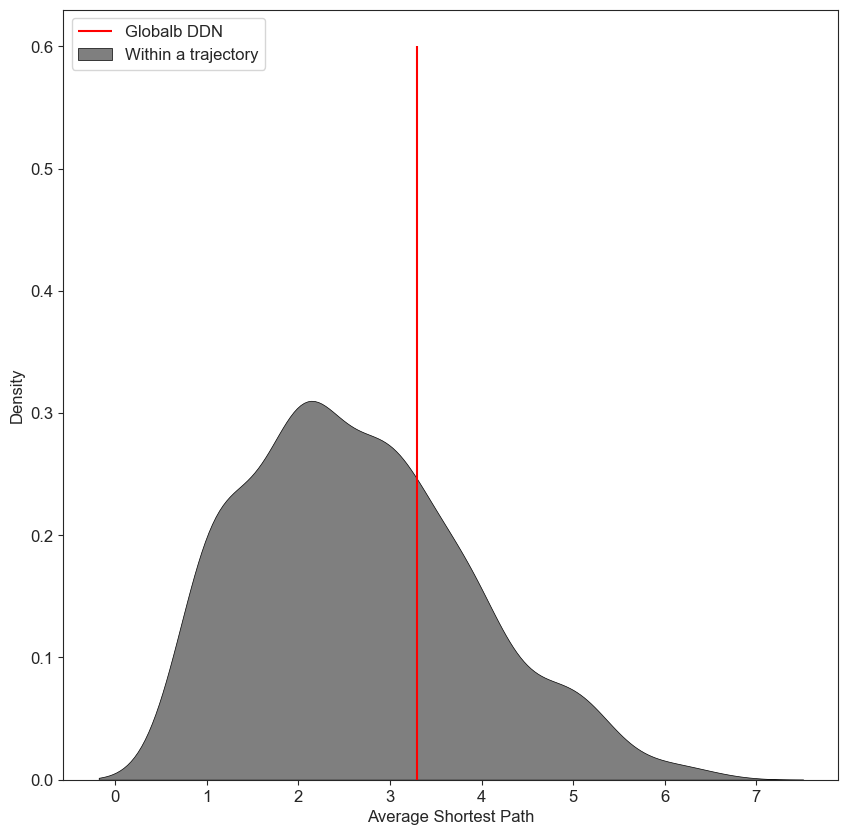

In [45]:
#Let's plot the distribution of all lcc z-scores

# plot distributions for non-sampled case
sns.set_style('white')
sns.set_style("ticks", {"xtick.major.size": 15, "ytick.major.size": 15})
plt.figure(figsize=(10,10))
plt.vlines(G_gene_icd_disp_significant_post_avg_sp,ymin=0,ymax=0.6,color='r',label='Globalb DDN')
sns.kdeplot(list(female_trajectories_dict_filtered_unique_DDN_avgsp.values()),color='k',lw=.5,alpha=.5,fill=True,label='Within a trajectory')

plt.legend(loc='upper left',fontsize=12)
plt.ylabel('Density',fontsize=12)
plt.xlabel('Average Shortest Path',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.savefig('Figures/DDN_ShortestPath_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")

In [86]:

female_trajectories_dict_filtered_unique_DDN_avgsp_sort = {k: v for k, v in sorted(female_trajectories_dict_filtered_unique_DDN_avgsp.items(), key=lambda item: item[1],reverse=False)}




In [ ]:
#Let's calculate the genetic (largest connected component) z-score of the genese perturbed by each trajectory

In [87]:
female_trajectories_dict_filtered_unique_distinct_zscore_dict={}
female_trajectories_dict_filtered_unique_agglomerated_zscore_dict={}

for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
    z_score_list=[]
    for dis in dislist:
        z_score_list.append(allsources_icd_gene_dict_unified_lcczscore[dis])
    female_trajectories_dict_filtered_unique_distinct_zscore_dict[agg_trj]=z_score_list
    
for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
    tot_genelsit=[]
    for dis in dislist:
        for gene in allsources_icd_gene_dict_unified[dis]:
            if gene not in tot_genelsit:
                tot_genelsit.append(gene)
    female_trajectories_dict_filtered_unique_agglomerated_zscore_dict[agg_trj]=net_modularity(tot_genelsit,G_ppi)
    

In [88]:
with open('output/female_trajectories_dict_filtered_unique_agglomerated_zscore_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(female_trajectories_dict_filtered_unique_agglomerated_zscore_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_14869/762931689.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(comparing_group_list,


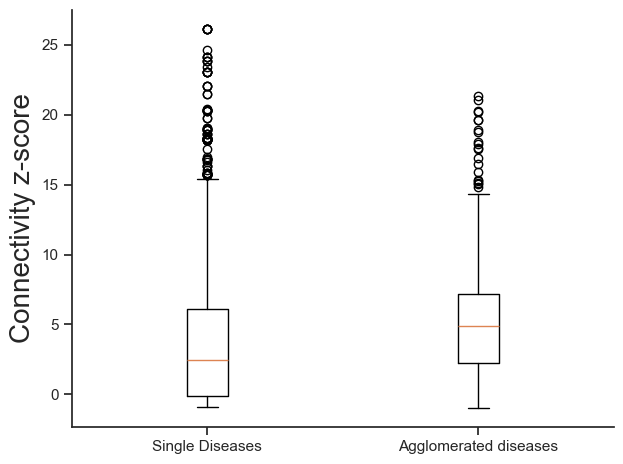

In [89]:
#Let's plot these boxplots

z_score_single_diseases=[]
z_score_agglomerated_diseases=[round(float(z),3) for z in female_trajectories_dict_filtered_unique_agglomerated_zscore_dict.values() if z!='nan']

for trj,z_scorelist in female_trajectories_dict_filtered_unique_distinct_zscore_dict.items():
    for z in z_scorelist:
        if z!='nan':
            z_score_single_diseases.append(round(float(z),3))
            

import matplotlib.ticker
fig1, ax1 = plt.subplots()
labels=['Single Diseases','Agglomerated diseases']
plt.ylabel('Connectivity z-score',fontsize=20)
#plt.xlabel('Jaccard index',fontsize=20)
#plt.yscale('log')
comparing_group_list=[z_score_single_diseases,z_score_agglomerated_diseases]
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
bplot = plt.boxplot(comparing_group_list,
                     notch=False,  # notch shape
                     vert=True,  # vertical box alignment  
                     labels=labels)  # will be used to label x-ticks

plt.tight_layout()

plt.show()

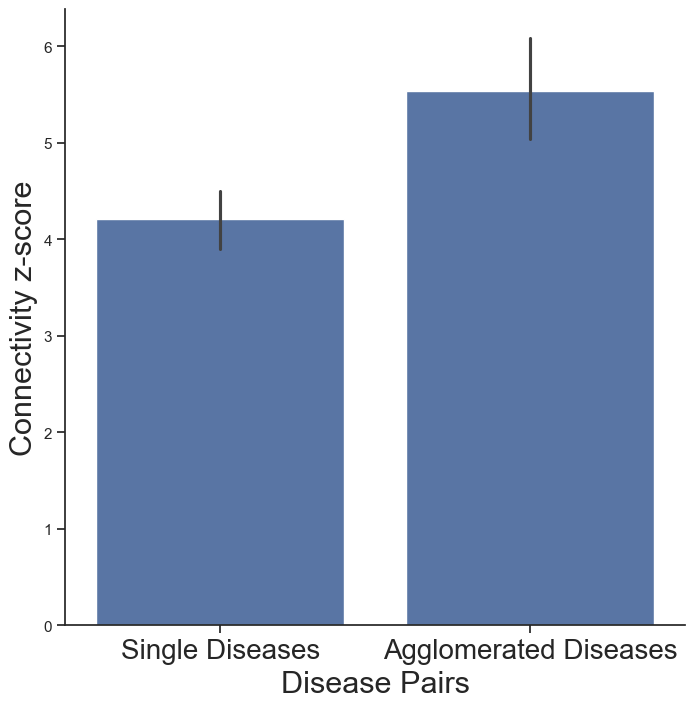

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

connectivity_df=pd.DataFrame()

status_list=[]
conn_list=[]

for i in z_score_single_diseases:
    status_list.append("Single Diseases")
    conn_list.append(i)
    
for i in z_score_agglomerated_diseases:
    status_list.append("Agglomerated Diseases")
    conn_list.append(i)

connectivity_df['Status']=status_list
connectivity_df['Connectivity']=conn_list

# Create a boxplot using seaborn
fig, ax = plt.subplots(figsize=(8, 8))
sns.set(style="white")

g=sns.barplot(x='Status', y='Connectivity', data=connectivity_df)
#g.set_yscale("log")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

plt.xticks(fontsize=20)

plt.xlabel('Disease Pairs', fontsize=22)
plt.ylabel('Connectivity z-score', fontsize=22)
plt.savefig('Figures/Agglomerate_PPI_zscore_Female_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()

In [91]:

from scipy import stats
import numpy as np


t_value,p_value=stats.ttest_ind(z_score_single_diseases,z_score_agglomerated_diseases)
p_value

9.882760036392942e-05

In [ ]:
#Let's create a network now out of this condensed unique trajectories
#We are going to focus on those trajectories that have less than 8 elements because we have shown that those are the ones
#that have the highest coherence with the genetic basis
G_elma_icd_female = nx.Graph() 

for dislist in list(female_trajectories_dict_filtered_unique.values()):
    if len(dislist)<8:
        for dis1 in dislist:
            for dis2 in dislist:
                if dis1!=dis2:
                    G_elma_icd_female.add_edge(dis1, dis2)
                
print(G_elma_icd_female.number_of_nodes())
print(G_elma_icd_female.number_of_edges())

378
1107


In [93]:
G_elma_icd_female_df = nx.to_pandas_edgelist(G_elma_icd_female,'Dis A', 'Dis B')
G_elma_icd_female_df.to_csv('output/G_elma_icd_female_df_v2026_official.tsv', sep = '\t')

In [105]:
from cartoGRAPHs import *
import random 
from sklearn.decomposition import PCA
from sklearn import preprocessing
import json
import matplotlib.colors as mcolors
import colorsys
import pickle as pk

In [106]:
icd_cat = set([str(n[0]) for n in G_elma_icd_female.nodes()])

In [107]:
icd_code_comm = {}
for icd in icd_cat:
    nodelist = []
    for node in G_elma_icd_female.nodes():
        if icd in node:
            nodelist.append(node)
    icd_code_comm[icd] = nodelist

In [108]:
# creating a feature dataframe based on community
feature_df = pd.DataFrame()
    
for g in G_elma_icd_female.nodes():
    feature_list=[]
    for icd, nodelist in icd_code_comm.items():
        if g in nodelist:
            feature_list.append(1)
        else:
            feature_list.append(0)
    feature_df[g]=feature_list


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_33382/4041629977.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_33382/4041629977.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df[g]=feature_list
/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_33382/4041629977.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [109]:
feature_df_T=feature_df.T

In [110]:
r = 0.9
alpha = 1.0

A = nx.adjacency_matrix(G_elma_icd_female, nodelist=list(G_elma_icd_female.nodes()))
DM_m = rnd_walk_matrix2(A, r, alpha, len(G_elma_icd_female.nodes()))
FM_structural = pd.DataFrame(DM_m)
FM_structural.sum(axis=1) # axis=1 for columns i.e. features = sum 1
FM_structural.index=list(G_elma_icd_female.nodes())
FM_structural.columns=list(G_elma_icd_female.nodes())
FM_structural

,K56,K59,A38,B01,H61,J38,A41,C91,B00,B99,...,H16,E53,I13,M10,G31,I31,I48,J42,J81,J47
K56,9.010182e-01,9.017272e-03,5.422219e-09,5.422219e-09,2.686957e-09,1.545574e-07,5.697375e-05,5.697375e-06,2.760917e-06,3.850704e-06,...,3.502798e-08,1.876234e-08,1.876234e-08,1.064407e-08,2.053409e-09,1.183187e-08,1.183187e-08,1.183187e-08,1.183187e-08,2.104537e-08
K59,1.288182e-02,9.008022e-01,1.124493e-08,1.124493e-08,1.664262e-08,3.094603e-07,3.924899e-05,3.924899e-06,6.395946e-05,8.918791e-05,...,3.461791e-06,4.318847e-07,4.318847e-07,5.821802e-09,1.850228e-07,6.358753e-09,6.358753e-09,6.358753e-09,6.358753e-09,1.406024e-08
A38,2.323808e-09,3.373479e-09,9.015302e-01,3.056247e-02,1.170950e-02,3.634283e-03,1.719988e-07,1.719988e-08,1.252601e-06,4.549506e-07,...,1.742812e-10,3.190052e-09,3.190052e-09,5.120026e-09,3.630921e-12,2.422945e-09,2.422945e-09,2.422945e-09,2.422945e-09,3.404548e-08
B01,2.323808e-09,3.373479e-09,3.056247e-02,9.015302e-01,1.170950e-02,3.634283e-03,1.719988e-07,1.719988e-08,1.252601e-06,4.549506e-07,...,1.742812e-10,3.190052e-09,3.190052e-09,5.120026e-09,3.630921e-12,2.422945e-09,2.422945e-09,2.422945e-09,2.422945e-09,3.404548e-08
H61,3.070808e-09,1.331410e-08,3.122535e-02,3.122535e-02,9.018219e-01,3.713116e-03,1.788905e-07,1.788905e-08,7.263970e-05,1.808320e-06,...,6.700470e-10,5.887990e-09,5.887990e-09,7.880011e-09,1.185168e-11,5.449355e-09,5.449355e-09,5.449355e-09,5.449355e-09,3.482922e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
I31,1.352214e-08,5.087002e-09,6.461187e-09,6.461187e-09,5.449355e-09,1.819251e-07,1.255926e-08,1.255926e-09,1.682179e-07,2.250717e-07,...,8.347753e-11,4.281737e-05,4.281737e-05,1.066308e-02,6.049360e-13,9.008663e-01,1.197737e-02,1.197737e-02,1.197737e-02,1.004963e-07
I48,1.352214e-08,5.087002e-09,6.461187e-09,6.461187e-09,5.449355e-09,1.819251e-07,1.255926e-08,1.255926e-09,1.682179e-07,2.250717e-07,...,8.347753e-11,4.281737e-05,4.281737e-05,1.066308e-02,6.049360e-13,1.197737e-02,9.008663e-01,1.197737e-02,1.197737e-02,1.004963e-07
J42,1.352214e-08,5.087002e-09,6.461187e-09,6.461187e-09,5.449355e-09,1.819251e-07,1.255926e-08,1.255926e-09,1.682179e-07,2.250717e-07,...,8.347753e-11,4.281737e-05,4.281737e-05,1.066308e-02,6.049360e-13,1.197737e-02,1.197737e-02,9.008663e-01,1.197737e-02,1.004963e-07
J81,1.352214e-08,5.087002e-09,6.461187e-09,6.461187e-09,5.449355e-09,1.819251e-07,1.255926e-08,1.255926e-09,1.682179e-07,2.250717e-07,...,8.347753e-11,4.281737e-05,4.281737e-05,1.066308e-02,6.049360e-13,1.197737e-02,1.197737e-02,1.197737e-02,9.008663e-01,1.004963e-07


In [111]:
scalar_val = 0.55
layout_method = 'modulated-scal'+str(scalar_val)
DF_structural = FM_structural
DF_functional = feature_df
DF_merge = feature_modulation(DF_structural,DF_functional, scalar_val)

n_n = 10
spr = 2
md = 1.5
metr2D = 'cosine'

posG2D_modulated = layout_portrait_umap(G_elma_icd_female,
                                   DF_merge,
                                   2,
                                   n_neighbors=n_n, 
                                   spread=spr, 
                                   min_dist=md, 
                                   metric=metr2D
                                  )

posG2D_new = posG2D_modulated

/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [112]:
opacity_nodes = 0.9
node_edge_col = '#000000' 
node_linewidth = 0.1

edge_opacity = 0.5
edge_width = 0.1
edge_color = '#A1A1A1' #'#6C6C6C' #'#d3d3d3'

In [113]:
with open('output/icd_cat_color_mapping.pickle', 'rb') as handle:
    icd_cat_color_mapping = pk.load(handle)

In [114]:
def draw_node_degree(G, scalef):
    '''
    Calculate the node degree from graph positions (dict).
    Return list of radii for each node (2D). 
    '''
    
    l_size = {}
    for node in G.nodes():
        k = nx.degree(G, node)
        if k > 0:
            R = k*scalef +0.25 #math.log(k) * scalef + 0.25
        else: 
            R = 0.1
        l_size[node] = R
        
    return l_size

scale_factor = 15 #0.15
d_size = draw_node_degree(G_elma_icd_female, scale_factor)
l_size = [d_size[n] for n in posG2D_new.keys()]

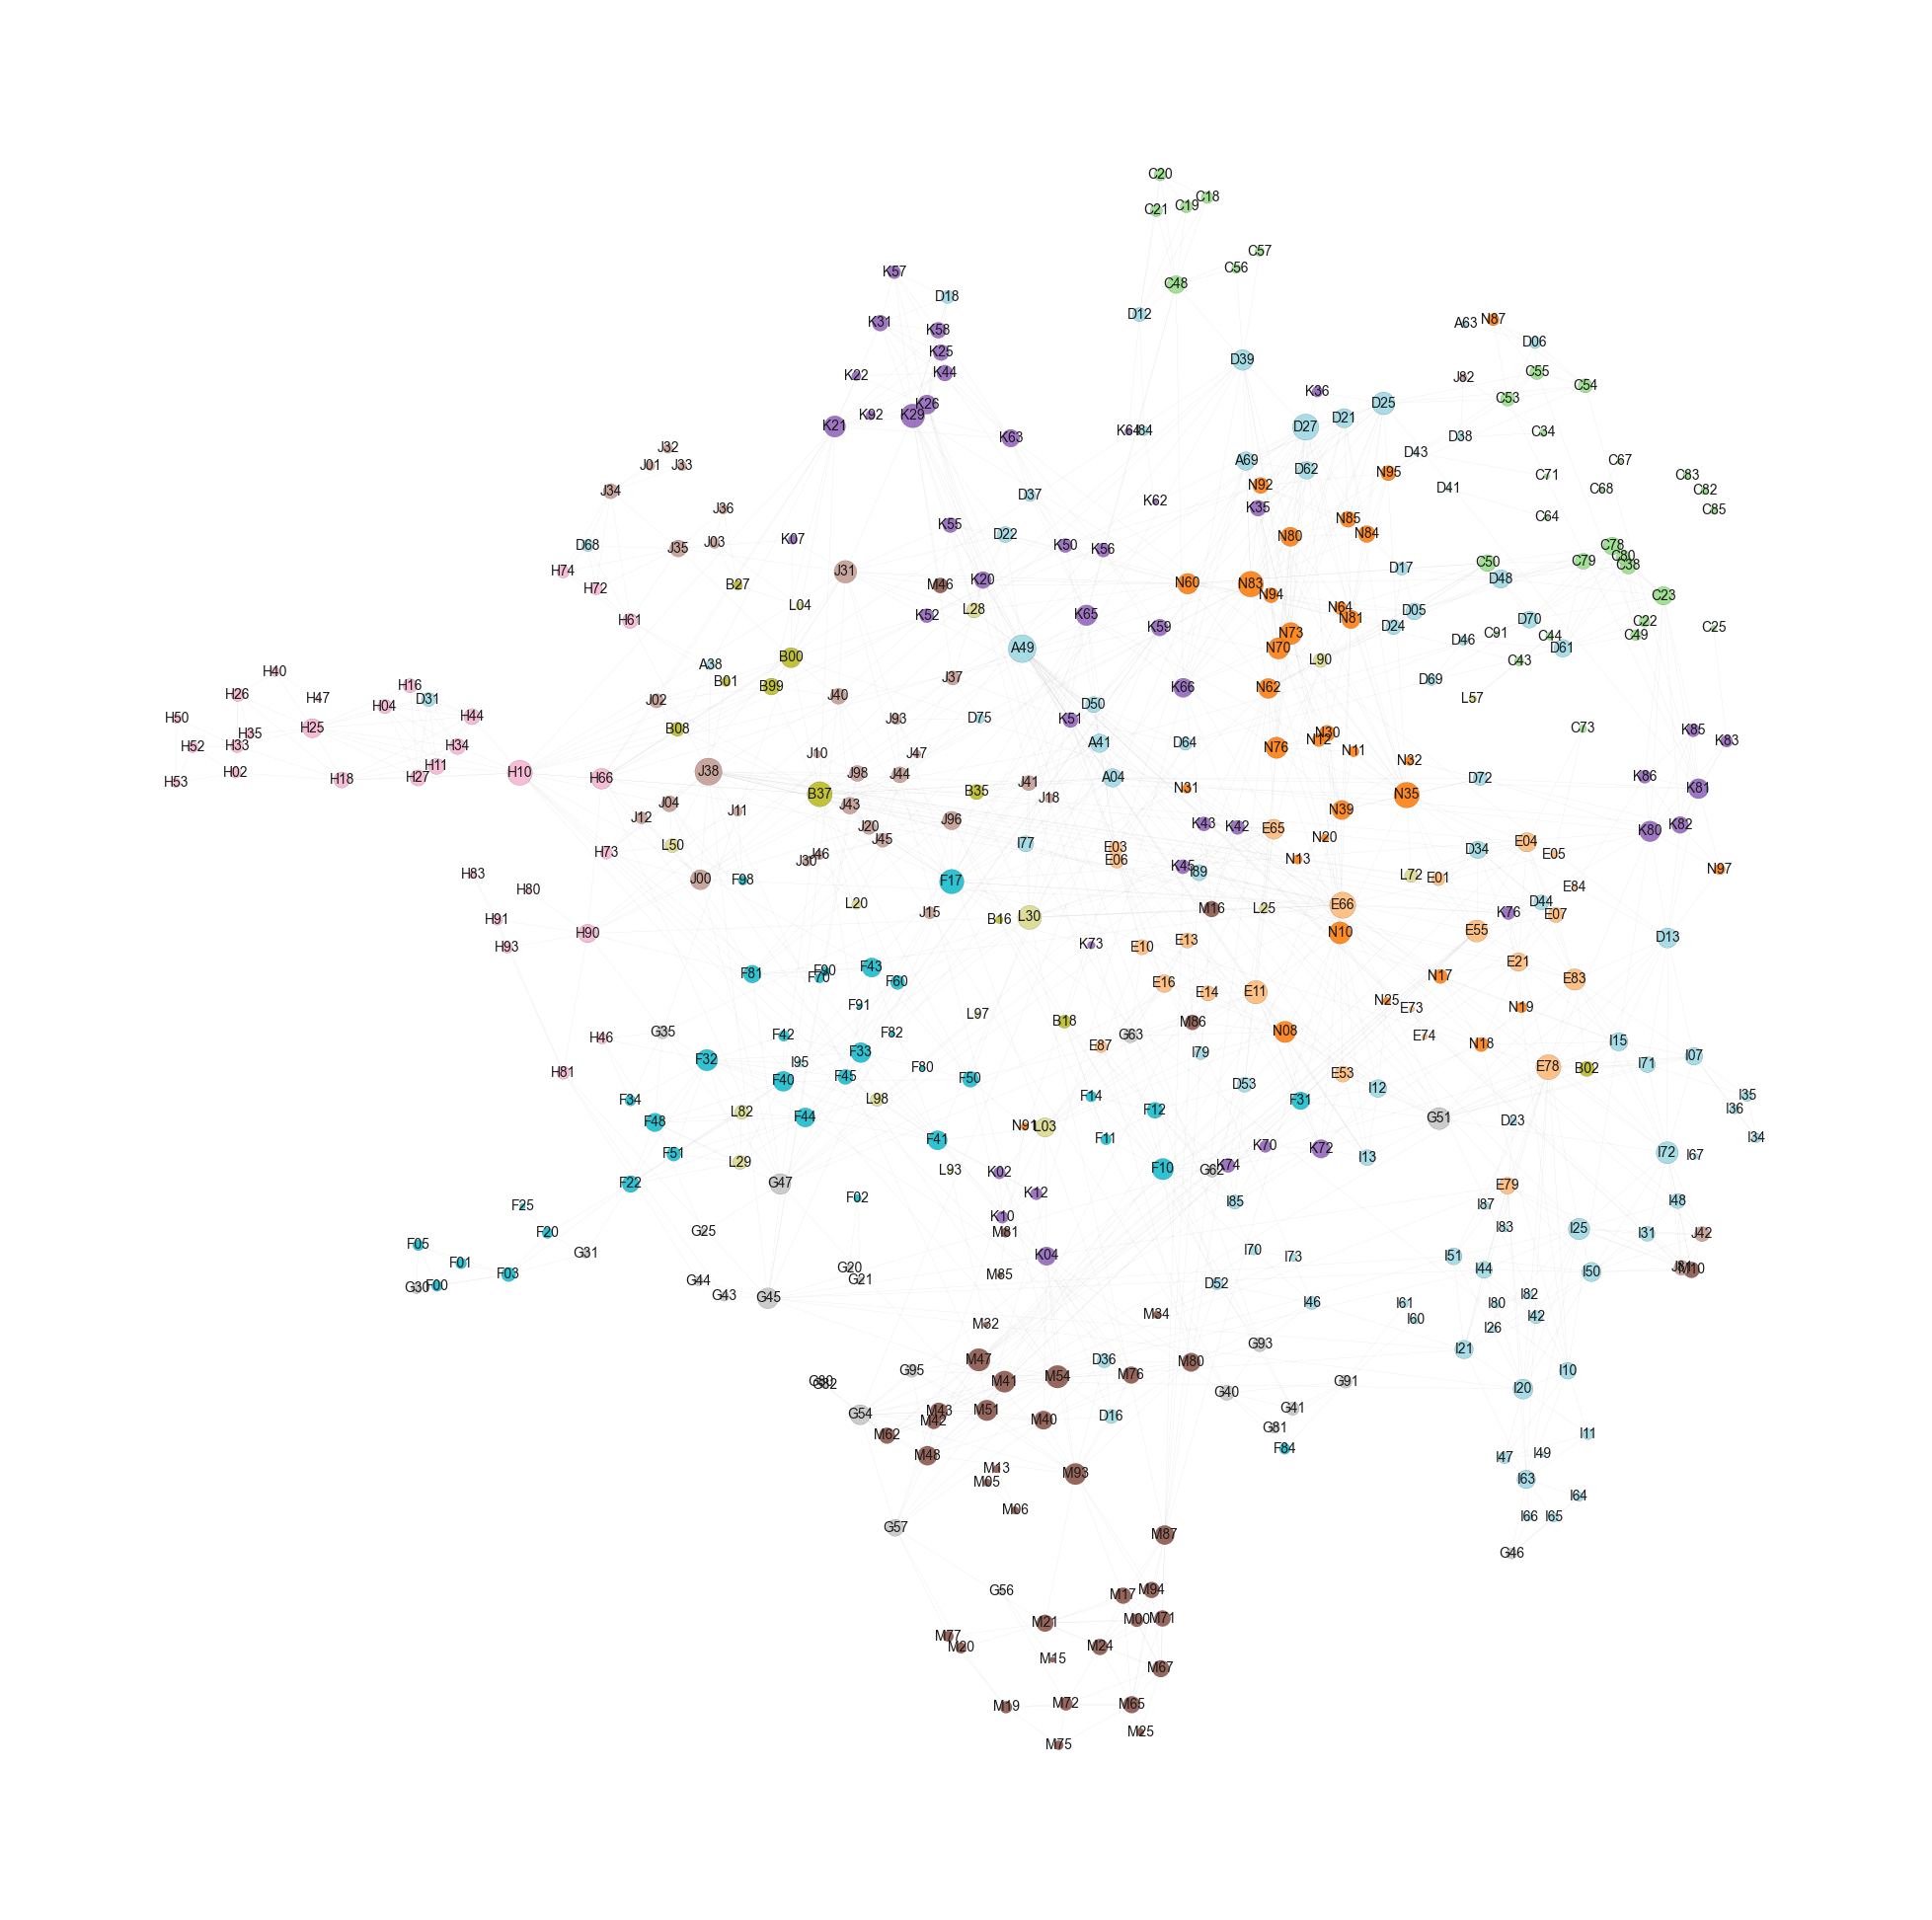

In [115]:
color_list = []
for node in posG2D_new.keys():
    color_list.append(icd_cat_color_mapping[node[0]])


plt.figure(figsize=(25,25))
nx.draw_networkx_nodes(G_elma_icd_female, 
                       posG2D_new,
                       edgecolors = node_edge_col, 
                       linewidths = node_linewidth, 
                       node_color = color_list, 
                       node_size = l_size, 
                       alpha = opacity_nodes)

nx.draw_networkx_edges(G_elma_icd_female, posG2D_new,  width = edge_width, edge_color = edge_color, alpha = edge_opacity)
plt.box(False)
nx.draw_networkx_labels(G_elma_icd_female,pos=posG2D_new,font_size=10)
plt.savefig('Figures/Supp_EpiNet_DDN_Female_v2026.pdf',format='pdf',dpi=300, bbox_inches = "tight")
plt.show()



In [50]:

G_elma_icd_female_df = pd.read_csv('output/G_elma_icd_female_df_v2026_official.tsv', sep="\t",index_col=0)
G_elma_icd_female_nx = nx.from_pandas_edgelist(G_elma_icd_female_df, 'Dis A', 'Dis B')

In [48]:
for e in G_elma_icd_male_nx.edges():
    if "F17" in e:
        if e not in G_elma_icd_female_nx.edges() and (e[1],e[0]) not in G_elma_icd_female_nx.edges():
            print(e)

('J04', 'F17')
('N62', 'F17')
('K04', 'F17')
('J37', 'F17')
('F17', 'J42')
('F17', 'J01')
('F17', 'E87')
('F17', 'F10')
('F17', 'F12')
('F17', 'F20')
('F17', 'F60')
('F17', 'F63')
('F17', 'J93')
('F17', 'J15')
('F17', 'L05')
('F17', 'D52')
('F17', 'J41')
('F17', 'L71')
('F17', 'J13')
('F17', 'J39')
('F17', 'K08')
('F17', 'K12')
('F17', 'L08')
('F17', 'J02')
('F17', 'D51')
('F17', 'H49')
('F17', 'J82')


In [49]:
for e in G_elma_icd_female_nx.edges():
    if "F10" in e:
        if e not in G_elma_icd_male_nx.edges() and (e[1],e[0]) not in G_elma_icd_male_nx.edges():
            print(e)

('F10', 'B18')
('F10', 'F11')
('F10', 'F14')
('F10', 'F19')
('F10', 'G62')
('F10', 'I85')
('F10', 'K74')
('F10', 'D52')
('F10', 'G93')
('F10', 'I46')
('F10', 'K26')
('F10', 'M80')


In [45]:
G_elma_icd_female_degree=dict(nx.degree(G_elma_icd_female_nx))
dict(sorted(G_elma_icd_female_degree.items(), key=lambda item: item[1],reverse=True))

{'J38': 22,
 'F10': 18,
 'E66': 18,
 'H10': 17,
 'F13': 16,
 'F33': 15,
 'F41': 15,
 'N35': 15,
 'N76': 15,
 'N83': 15,
 'K80': 15,
 'K29': 15,
 'F43': 14,
 'L03': 14,
 'K81': 14,
 'K26': 14,
 'F17': 13,
 'N39': 13,
 'G47': 13,
 'D25': 13,
 'K59': 12,
 'J35': 12,
 'J00': 12,
 'J96': 12,
 'J31': 12,
 'N81': 12,
 'M51': 12,
 'I63': 12,
 'E65': 11,
 'K08': 11,
 'N92': 11,
 'D61': 11,
 'E16': 11,
 'E11': 11,
 'F12': 11,
 'N80': 11,
 'N84': 11,
 'F32': 11,
 'F19': 11,
 'K63': 10,
 'K66': 10,
 'J34': 10,
 'J04': 10,
 'J40': 10,
 'J43': 10,
 'D50': 10,
 'K51': 10,
 'D70': 10,
 'H90': 10,
 'I10': 10,
 'N85': 10,
 'I21': 10,
 'I20': 10,
 'K82': 10,
 'N88': 10,
 'N95': 10,
 'M65': 10,
 'M67': 10,
 'M21': 10,
 'C50': 10,
 'D05': 10,
 'H25': 10,
 'K65': 9,
 'C48': 9,
 'B37': 9,
 'F45': 9,
 'H61': 9,
 'E04': 9,
 'G83': 9,
 'N30': 9,
 'J44': 9,
 'C78': 9,
 'F50': 9,
 'F81': 9,
 'E78': 9,
 'I25': 9,
 'K21': 9,
 'K25': 9,
 'K31': 9,
 'K58': 9,
 'M24': 9,
 'M94': 9,
 'M17': 9,
 'M71': 9,
 'G57': 9,
 'H

In [95]:
for e in G_elma_icd_female.edges():
    if 'F17' in e:
        print(e)

('J38', 'F17')
('J40', 'F17')
('J20', 'F17')
('J98', 'F17')
('E66', 'F17')
('E78', 'F17')
('F17', 'I10')
('F17', 'K76')
('F17', 'K80')
('F17', 'J44')
('F17', 'J43')
('F17', 'J96')
('F17', 'G45')


In [96]:
mf_intersection = set(dict(G_elma_icd_female['F17']).keys()) & set(dict(G_elma_icd_male['F17']).keys())
for dis in set(dict(G_elma_icd_male['F17']).keys()):
    if dis not in mf_intersection:
        print(dis)


D51
J13
N62
K04
L71
J39
J37
J15
J82
K12
L08
J93
F60
J42
F20
J01
F10
L05
J02
F63
F12
H49
D52
J41
E87
J04
K08


In [97]:
#Extract degrees from the DDN
degrees_DDN = [x[1] for x in  nx.degree(G_elma_icd_female)]
#Get the unique PPI degree steps

degrees_DDN_unique = list(set(degrees_DDN))
degrees_DDN_unique.sort()

#degree for x axis (sorted from small to biggest)
degreesDDN = []

#Normal distribution (i.e. P(k = x))
degreeDistributionDDN = []
degreeDistributionDDNcount = []

for degree in degrees_DDN_unique:
    degreesDDN.append(degree)
    degreeDistributionDDN.append(degrees_DDN.count(degree)/float(len(degrees_DDN)))
    degreeDistributionDDNcount.append(degrees_DDN.count(degree))

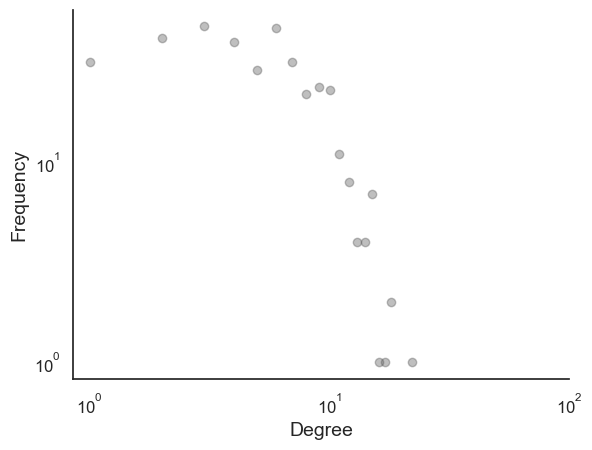

In [98]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import figure
from matplotlib.ticker import MaxNLocator

#Let's plot the Degree distribution of the EEN
fig1, ax1 = plt.subplots()
plt.scatter(degreesDDN, degreeDistributionDDNcount, c='#5F5F5F', alpha=0.4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
ax1.set_xticks([1,10, 100])

plt.xticks(fontsize=12, rotation=0)
plt.yticks(fontsize=12, rotation=0)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(True)
ax1.spines['left'].set_visible(True)
plt.savefig('Figures/EpidemiologicalcNetwork_DegreeDistributionFemale_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 

plt.show()
plt.close()

In [99]:

genetic_edges = []
tot_edges = []

for e in G_gene_icd_disp_significant_post.edges():
    if e[0] in G_elma_icd_female.nodes() and e[1] in G_elma_icd_female.nodes():
        genetic_edges.append(e)
        tot_edges.append(e)
        
for e in G_elma_icd_female.edges():
    if e not in tot_edges:
        tot_edges.append(e)

In [58]:
female_shared_gen_epi_edges = []

for e in genetic_edges:
    if (e[0],e[1]) in G_elma_icd_female_nx.edges() or (e[1],e[0]) in G_elma_icd_female_nx.edges():
        female_shared_gen_epi_edges.append(e)

for e in G_elma_icd_female_nx.edges():
    if (e[0],e[1]) in genetic_edges or (e[1],e[0]) in genetic_edges:
        if e not in female_shared_gen_epi_edges:
            female_shared_gen_epi_edges.append(e)
len(female_shared_gen_epi_edges)

176

In [64]:
female_trj_with_genetic_basis = []
female_trj_with_genetic_basis_dict = {}
for trj,dislist in female_trajectories_dict_filtered_unique.items():
    pairwise_dislist = list(it.combinations(dislist,2))
    trj_gen_epi_distlist = []
    for dispair in pairwise_dislist:
        if (dispair[0],dispair[1]) in female_shared_gen_epi_edges or (dispair[1],dispair[0]) in female_shared_gen_epi_edges:
            trj_gen_epi_distlist.append(dispair)
    female_trj_with_genetic_basis_dict[trj] = len(trj_gen_epi_distlist)/len(pairwise_dislist)
    if len(trj_gen_epi_distlist)>0:
        female_trj_with_genetic_basis.append(trj)
female_trj_with_genetic_basis_dict = dict(sorted(female_trj_with_genetic_basis_dict.items(), key=lambda item: item[1],reverse=True))

In [67]:
len(female_trj_with_genetic_basis)

122

In [65]:
ml_shared_gen_epi_edges = [] 
for dispair in female_shared_gen_epi_edges:
    if (dispair[0],dispair[1]) in male_shared_gen_epi_edges or (dispair[1],dispair[0]) in male_shared_gen_epi_edges:
        ml_shared_gen_epi_edges.append(dispair)

for dispair in male_shared_gen_epi_edges:
    if (dispair[0],dispair[1]) in female_shared_gen_epi_edges or (dispair[1],dispair[0]) in female_shared_gen_epi_edges:
        if dispair not in ml_shared_gen_epi_edges:
            ml_shared_gen_epi_edges.append(dispair)

print(len(ml_shared_gen_epi_edges))

127


In [63]:
male_trj_with_genetic_basis = []
male_trj_with_genetic_basis_dict = {}
for trj,dislist in male_trajectories_dict_filtered_unique.items():
    pairwise_dislist = list(it.combinations(dislist,2))
    trj_gen_epi_distlist = []
    for dispair in pairwise_dislist:
        if (dispair[0],dispair[1]) in male_shared_gen_epi_edges or (dispair[1],dispair[0]) in male_shared_gen_epi_edges:
            trj_gen_epi_distlist.append(dispair)
    male_trj_with_genetic_basis_dict[trj] = len(trj_gen_epi_distlist)/len(pairwise_dislist)
    if len(trj_gen_epi_distlist)>0:
        male_trj_with_genetic_basis.append(trj)
male_trj_with_genetic_basis_dict = dict(sorted(male_trj_with_genetic_basis_dict.items(), key=lambda item: item[1],reverse=True))

In [64]:
trj_list = []
gen_proportion_list = []

for trj,prop in male_trj_with_genetic_basis_dict.items():
    trj_list.append(trj)
    gen_proportion_list.append(prop)
    
male_trj_with_genetic_basis_df = pd.DataFrame()
male_trj_with_genetic_basis_df["trj"] = trj_list
male_trj_with_genetic_basis_df["genetic_proportion"] = gen_proportion_list
male_trj_with_genetic_basis_df.to_csv("output/Male_trajectory_genetic_base_proportion_2026_official.csv")


In [74]:
trj_list = []
gen_proportion_list = []

for trj,prop in female_trj_with_genetic_basis_dict.items():
    trj_list.append(trj)
    gen_proportion_list.append(prop)
    
female_trj_with_genetic_basis_df = pd.DataFrame()
female_trj_with_genetic_basis_df["trj"] = trj_list
female_trj_with_genetic_basis_df["genetic_proportion"] = gen_proportion_list
female_trj_with_genetic_basis_df.to_csv("output/Female_trajectory_genetic_base_proportion_2026_official.csv")


In [75]:
len([k for k,v in male_trj_with_genetic_basis_dict.items() if v==1])

31

In [76]:
len([k for k,v in female_trj_with_genetic_basis_dict.items() if v==1])

21

In [80]:
for trj in [k for k,v in male_trj_with_genetic_basis_dict.items() if v==1]:
    print(male_trajectories_dict_filtered_unique[trj])

['E10', 'E14', 'E16']
['H90', 'H91']
['C71', 'D43']
['F11', 'F13', 'F19']
['B20', 'B24']
['N18', 'D64', 'N19']
['I26', 'I80']
['I42', 'I50']
['N18', 'D64']
['E04', 'E05']
['I20', 'I21', 'I25']
['I35', 'I71']
['I73', 'I74']
['K40', 'K42', 'K43']
['C15', 'C16']
['C43', 'D22']
['C92', 'D46']
['D68', 'I26', 'I80', 'I82']
['I35', 'I71', 'I72']
['K25', 'K26']
['L97', 'L98']
['L98', 'M86']
['G30', 'F00']
['I71', 'I72']
['C44', 'L57', 'D23']
['M07', 'L40']
['C25', 'C24']
['C91', 'D80']
['I26', 'I80', 'I82']
['L98', 'M86', 'L97']
['L97', 'L98', 'M86']


In [106]:
len(male_trj_with_genetic_basis)/len(male_trajectories_dict_filtered_unique)

0.48632218844984804

In [107]:
for trj in male_trj_with_genetic_basis:
    try:
        print(trj,male_trajectories_dict[int(trj)])
    except:
        pass

1 ['K35-10-19', 'K37-10-19', 'K56-10-19', 'K65-10-19']
10 ['J20-0-9', 'J30-0-9', 'J42-0-9', 'L30-0-9', 'D80-10-19']
12 ['D61-0-9', 'D69-0-9', 'D70-0-9']
13 ['D80-0-9', 'E61-0-9', 'G00-0-9', 'H02-0-9', 'H04-0-9', 'J01-0-9', 'K00-0-9', 'K76-0-9', 'M43-0-9', 'J35-10-19', 'J36-10-19']
18 ['E66-0-9', 'E66-10-19', 'E78-10-19', 'F17-10-19', 'I10-10-19', 'K76-10-19']
22 ['F43-0-9', 'F81-0-9', 'F43-10-19', 'F70-10-19', 'F81-10-19', 'F90-10-19']
23 ['E88-0-9', 'F79-0-9', 'G25-0-9', 'G41-0-9', 'I47-0-9', 'J69-0-9', 'G40-10-19', 'G41-10-19', 'J96-10-19', 'J96-20-29']
27 ['G40-0-9', 'G41-0-9', 'G47-0-9', 'G81-0-9', 'G91-0-9', 'G41-10-19', 'G47-10-19', 'G81-10-19', 'G91-10-19']
34 ['H69-0-9', 'J32-0-9', 'J35-0-9', 'J36-0-9']
36 ['H90-0-9', 'H91-0-9', 'H90-10-19', 'H91-10-19']
39 ['K21-0-9', 'K21-10-19', 'K29-10-19', 'K44-10-19', 'K52-10-19']
41 ['K40-0-9', 'K42-0-9', 'N43-0-9', 'K40-10-19', 'N43-10-19']
54 ['E87-10-19', 'F10-10-19', 'F17-10-19']
55 ['F11-10-19', 'F13-10-19', 'F19-10-19']
57 ['E87-10

In [108]:
for trj,dislsit in male_trajectories_dict_filtered_unique.items():
    if "A04" in dislsit:
        print(trj,dislsit)

2 ['A04', 'A08', 'F50']
219 ['I25', 'I27', 'I31', 'A04']
239 ['K76', 'A04', 'D61', 'E55', 'K46', 'K55', 'K75']
261 ['N25', 'N18', 'A04', 'B02', 'N03']
264 ['N39', 'A04', 'N30']


In [51]:
icd_1 = []
icd_2 = []
ji_list = []

for g_pair in G_elma_icd_female_nx.edges():
    icd_1.append(g_pair[0])
    icd_2.append(g_pair[1])
    ji_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[g_pair[0]],allsources_icd_gene_dict_unified[g_pair[1]]))

mol_DDN_df = pd.DataFrame({'icd_1':icd_1,'icd_2':icd_2,'ji':ji_list})
mol_DDN_df.to_csv('output/mol_female_DDN_v2026_official.csv',index=False)


In [52]:
icd_1 = []
icd_2 = []
ji_list = []
for g_pair in G_elma_icd_male_nx.edges():
    if g_pair in G_elma_icd_female_nx.edges() or (g_pair[1],g_pair[0]) in G_elma_icd_female_nx.edges():
        if g_pair in G_gene_icd_disp_significant_post.edges() or (g_pair[1],g_pair[0]) in G_gene_icd_disp_significant_post.edges():
            icd_1.append(g_pair[0])
            icd_2.append(g_pair[1])
            ji_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[g_pair[0]],allsources_icd_gene_dict_unified[g_pair[1]]))

mol_DDN_df = pd.DataFrame({'icd_1':icd_1,'icd_2':icd_2,'ji':ji_list})
mol_DDN_df.to_csv('output/mol_female_male_DDN_v2026_official.csv',index=False)

In [54]:
icd_1 = []
icd_2 = []
ji_list = []
for g_pair in G_elma_icd_male_nx.edges():
    if g_pair in G_elma_icd_female_nx.edges() or (g_pair[1],g_pair[0]) in G_elma_icd_female_nx.edges():
        icd_1.append(g_pair[0])
        icd_2.append(g_pair[1])
        ji_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[g_pair[0]],allsources_icd_gene_dict_unified[g_pair[1]]))

mol_DDN_df = pd.DataFrame({'icd_1':icd_1,'icd_2':icd_2,'ji':ji_list})
mol_DDN_df.to_csv('output/female_male_DDN_v2026_official.csv',index=False)

In [55]:
icd_1 = []
icd_2 = []
ji_list = []
for g_pair in G_elma_icd_male_nx.edges():
    if g_pair in G_gene_icd_disp_significant_post.edges() or (g_pair[1],g_pair[0]) in G_gene_icd_disp_significant_post.edges():
        icd_1.append(g_pair[0])
        icd_2.append(g_pair[1])
        ji_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[g_pair[0]],allsources_icd_gene_dict_unified[g_pair[1]]))

mol_DDN_df = pd.DataFrame({'icd_1':icd_1,'icd_2':icd_2,'ji':ji_list})
mol_DDN_df.to_csv('output/mol_male_DDN_v2026_official_only_overlapping.csv',index=False)

In [56]:
icd_1 = []
icd_2 = []
ji_list = []
for g_pair in G_elma_icd_female_nx.edges():
    if g_pair in G_gene_icd_disp_significant_post.edges() or (g_pair[1],g_pair[0]) in G_gene_icd_disp_significant_post.edges():
        icd_1.append(g_pair[0])
        icd_2.append(g_pair[1])
        ji_list.append(overlap_jaccard(allsources_icd_gene_dict_unified[g_pair[0]],allsources_icd_gene_dict_unified[g_pair[1]]))

mol_DDN_df = pd.DataFrame({'icd_1':icd_1,'icd_2':icd_2,'ji':ji_list})
mol_DDN_df.to_csv('output/mol_female_DDN_v2026_official_only_overlapping.csv',index=False)